In [ ]:
# Curta, Karen C. 2017. Dados de ocorrência de incêndios florestais espaciais para os Estados Unidos, 1992-2015 [FPA_FOD_20170508]. 4a Edição. Fort Collins, CO: Arquivo de Dados de Pesquisa do Serviço Florestal. https://doi.org/10.2737/RDS-2013-0009.4


import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split

conn = sqlite3.connect("./wildfires_dataset.sqlite")

query = """
SELECT
    FIRE_YEAR,
    DISCOVERY_DOY,
    STAT_CAUSE_DESCR,
    FIRE_SIZE,
    FIRE_SIZE_CLASS,
    LATITUDE,
    LONGITUDE,
    STATE
FROM Fires
"""

df = pd.read_sql_query(query, conn)

conn.close()

# === Configurações e Hiperparâmetros ===

TARGET = "FIRE_SIZE_CLASS"
TRAIN_SIZE = 100_000
TEST_SIZE = 10_000

FEATURES = {
    "localizacao": ["LATITUDE", "LONGITUDE"],
    "localizacao_estado_ano_diaAno": [ "LATITUDE", "LONGITUDE", "STATE", "FIRE_YEAR", "DISCOVERY_DOY" ],
    "localizacao_estado_causa": [ "LATITUDE", "LONGITUDE", "STATE", "DISCOVERY_DOY", "STAT_CAUSE_DESCR" ],
    "tempo": ["FIRE_YEAR", "DISCOVERY_DOY"],
    "causa": ["STAT_CAUSE_DESCR"],
    "estado": ["STATE"],
    "localizacao_tempo": ["LATITUDE", "LONGITUDE", "FIRE_YEAR", "DISCOVERY_DOY"],
    "localizacao_causa": ["LATITUDE", "LONGITUDE", "STAT_CAUSE_DESCR"],
    "localizacao_estado": ["LATITUDE", "LONGITUDE", "STATE"],
    "causa_estado": ["STAT_CAUSE_DESCR", "STATE"],
    "todos_sem_fire_size": [ "FIRE_YEAR", "DISCOVERY_DOY", "STAT_CAUSE_DESCR", "LATITUDE", "LONGITUDE", "STATE" ],
}

all_feature_columns = sorted(set().union(*FEATURES.values()))
feature_df = df[[TARGET, *all_feature_columns]].dropna().copy()
feature_df = feature_df[feature_df[TARGET].isin(list("ABCDEFG"))]
feature_sample = feature_df.sample(n=TRAIN_SIZE + TEST_SIZE, random_state=42)

train_df, test_df = train_test_split(
    feature_sample,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=feature_sample[TARGET],
)

y_train = train_df[TARGET]
y_test = test_df[TARGET]

# ---=== Funções e Métodos ===---


def create_pipeline(feature_columns, type_model):
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.compose import ColumnTransformer
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.neural_network import MLPClassifier

    numeric_columns = (
        train_df[feature_columns].select_dtypes(include="number").columns.tolist()
    )
    categorical_columns = [col for col in feature_columns if col not in numeric_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_columns),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ]
    )

    type_model_map = {
        "knn": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        "rf": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        "mlp": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=100,
            early_stopping=True,
            random_state=42,
        ),
    }

    if type_model not in type_model_map:
        raise ValueError(f"Modelo inválido: {type_model}. Use: {list(type_model_map.keys())}")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", type_model_map[type_model]),
        ]
    )

    return pipeline


def fit_accuracy_cm_f1(model, feature_columns, y_train_input=None, y_test_input=None):
    from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

    target_train = y_train if y_train_input is None else y_train_input
    target_test = y_test if y_test_input is None else y_test_input

    model.fit(train_df[feature_columns], target_train)
    y_pred = model.predict(test_df[feature_columns])

    accuracy = accuracy_score(target_test, y_pred)
    f1 = f1_score(target_test, y_pred, average="weighted")

    labels = model.classes_.tolist()
    cm = confusion_matrix(target_test, y_pred, labels=labels)

    return accuracy, cm, f1, labels


def show_feature_loading_status(feature_names, current_index, elapsed_times=None):
    from IPython.display import clear_output

    if elapsed_times is None:
        elapsed_times = {}

    clear_output(wait=True)
    print("Progresso por conjunto de features:\n")

    for idx, feature_name in enumerate(feature_names):
        if idx < current_index:
            elapsed = elapsed_times.get(feature_name)
            if elapsed is None:
                status = "✅"
            else:
                status = f"✅ ({elapsed:.2f}s)"
        elif idx == current_index:
            status = "🟡"
        else:
            status = "..."

        print(f"{feature_name} {status}")


def show_model_ranking(results):
    import matplotlib.pyplot as plt
    import seaborn as sns

    ranking_df = (
        pd.DataFrame(results)
        .sort_values(["accuracy", "f1_score"], ascending=False)
        .reset_index(drop=True)
    )
    ranking_df.insert(0, "ranking", ranking_df.index + 1)

    ranking_table = ranking_df[["ranking", "feature_set", "accuracy", "f1_score", "tempo_segundos"]].copy()
    ranking_table = ranking_table.rename(columns={"tempo_segundos": "tempo"})
    ranking_table["accuracy"] = ranking_table["accuracy"].map(lambda value: f"{value:.2%}")
    ranking_table["f1_score"] = ranking_table["f1_score"].map(lambda value: f"{value:.4f}")
    ranking_table["tempo"] = ranking_table["tempo"].map(lambda value: f"{value:.2f}s")

    display(ranking_table)

    print("\nMatriz de confusão por ranking:\n")
    for _, row in ranking_df.iterrows():
        print(f"Ranking {int(row['ranking'])} - {row['feature_set']} ({row['tempo_segundos']:.2f}s)")
        cm_df = pd.DataFrame(
            row["confusion_matrix"],
            index=row["labels"],
            columns=row["labels"],
        )

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm_df,
            annot=True,
            fmt="d",
            cmap="YlOrRd",
            cbar=True,
            linewidths=0.3,
            linecolor="white",
        )
        plt.title(f"Confusion Matrix - {row['feature_set']}")
        plt.xlabel("Predito")
        plt.ylabel("Real")
        plt.tight_layout()
        plt.show()

    return ranking_df


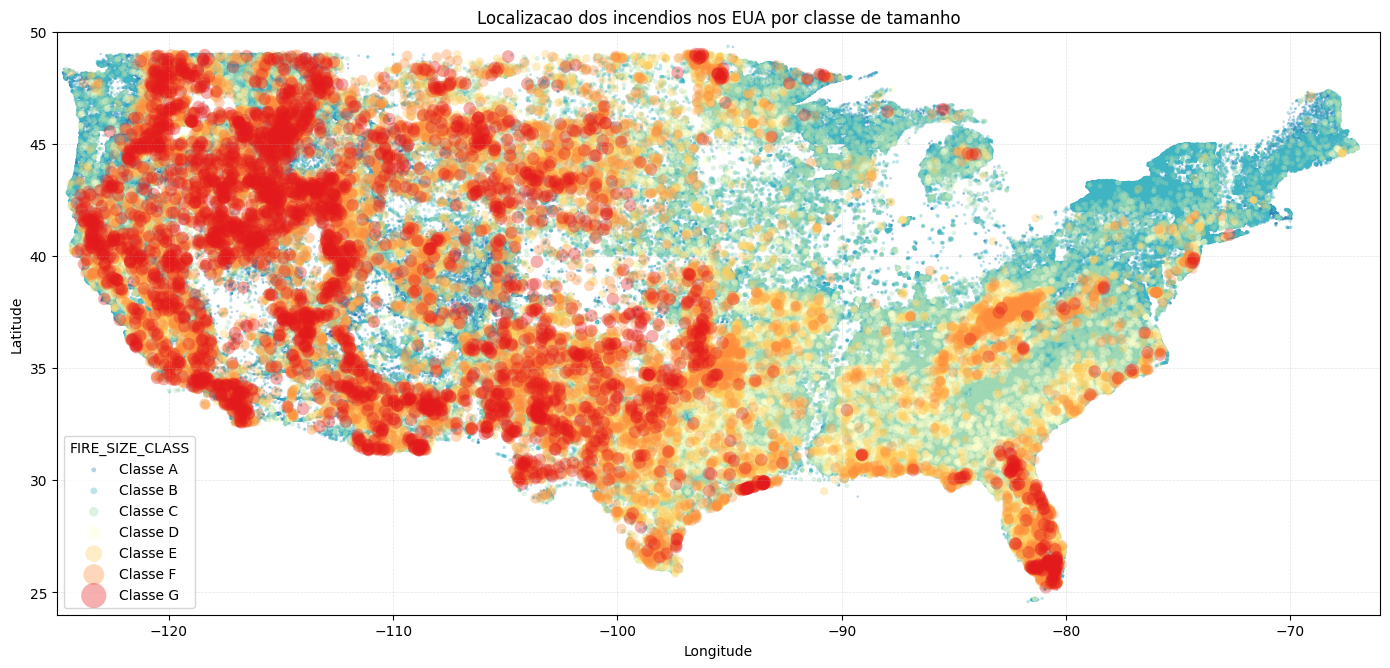

In [50]:
import matplotlib.pyplot as plt

fire_class_order = list("ABCDEFG")

# A = menor incendio, G = maior incendio. O valor controla o tamanho do ponto no scatter.
size_by_class = {
    "A": 3,
    "B": 6,
    "C": 12,
    "D": 22,
    "E": 36,
    "F": 56,
    "G": 82,
}

color_by_class = {
    "A": "#2c7fb8",
    "B": "#41b6c4",
    "C": "#a1dab4",
    "D": "#ffffcc",
    "E": "#fecc5c",
    "F": "#fd8d3c",
    "G": "#e31a1c",
}

plot_df = df.dropna(subset=["LATITUDE", "LONGITUDE", "FIRE_SIZE_CLASS"]).copy()
plot_df = plot_df[plot_df["FIRE_SIZE_CLASS"].isin(fire_class_order)]

# Mantem o mapa focado nos EUA continentais. Remova este filtro para incluir AK/HI/territorios.
plot_df = plot_df[
    plot_df["LATITUDE"].between(24, 50)
    & plot_df["LONGITUDE"].between(-125, -66)
]

fig, ax = plt.subplots(figsize=(14, 8))

for fire_class in fire_class_order:
    class_df = plot_df[plot_df["FIRE_SIZE_CLASS"] == fire_class]

    ax.scatter(
        class_df["LONGITUDE"],
        class_df["LATITUDE"],
        s=size_by_class[fire_class],
        color=color_by_class[fire_class],
        alpha=0.35,
        edgecolors="none",
        label=f"Classe {fire_class}",
    )

ax.set_title("Localizacao dos incendios nos EUA por classe de tamanho")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
ax.legend(title="FIRE_SIZE_CLASS", markerscale=2, frameon=True)

plt.tight_layout()
plt.show()

Progresso por conjunto de features:

localizacao ✅ (0.19s)
localizacao_estado_ano_diaAno ✅ (10.92s)
localizacao_estado_causa ✅ (10.59s)
tempo ✅ (0.14s)
causa ✅ (5.94s)
estado ✅ (4.93s)
localizacao_tempo ✅ (0.14s)
localizacao_causa ✅ (10.01s)
localizacao_estado ✅ (9.23s)
causa_estado ✅ (6.36s)
todos_sem_fire_size ✅ (10.97s)
duracao ✅ (0.34s)
duracao_localizacao ✅ (0.08s)
duracao_localizacao_causa ✅ (2.85s)
hora_descoberta ✅ (1.21s)
hora_localizacao ✅ (2.82s)
owner ✅ (0.65s)
owner_localizacao ✅ (0.14s)
owner_causa ✅ (8.92s)
county_localizacao ✅ (3.73s)
county_causa ✅ (2.52s)
completo_com_duracao ✅ (1.09s)


,ranking,feature_set,accuracy,f1_score,tempo
0,1,completo_com_duracao,60.25%,0.5823,1.09s
1,2,county_localizacao,58.69%,0.5649,3.73s
2,3,duracao_localizacao,58.55%,0.5648,0.08s
3,4,localizacao_causa,58.10%,0.5579,10.01s
4,5,todos_sem_fire_size,58.08%,0.5580,10.97s
5,6,duracao_localizacao_causa,57.92%,0.5577,2.85s
6,7,localizacao_estado_ano_diaAno,57.74%,0.5523,10.92s
7,8,localizacao_estado,57.68%,0.5536,9.23s
8,9,localizacao,57.68%,0.5535,0.19s
9,10,localizacao_estado_causa,57.60%,0.5512,10.59s



Matriz de confusão por ranking:

Ranking 1 - completo_com_duracao (1.09s)


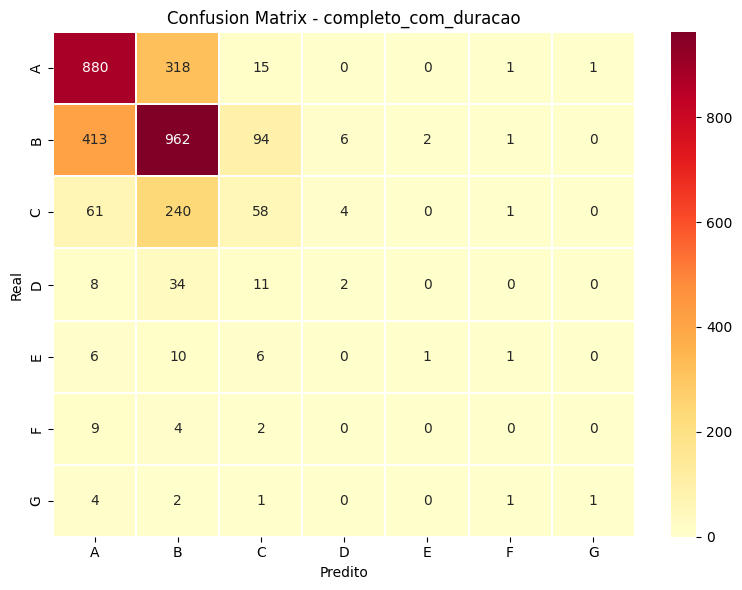

Ranking 2 - county_localizacao (3.73s)


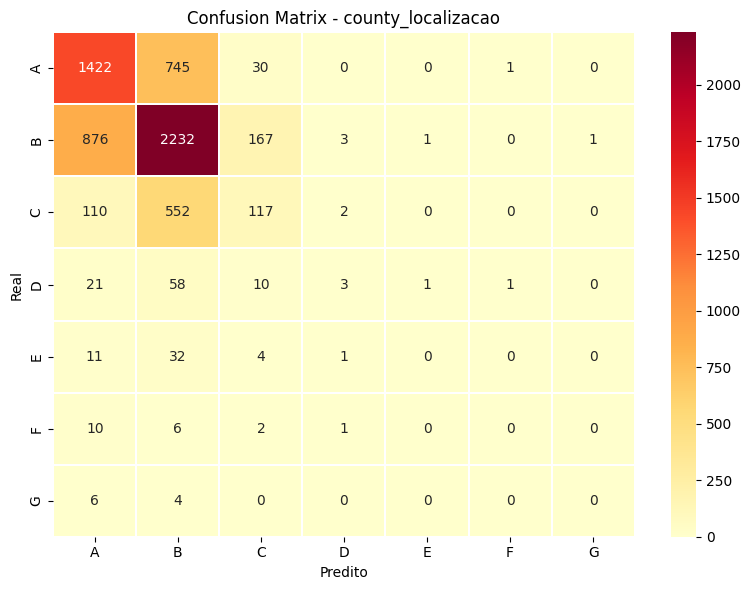

Ranking 3 - duracao_localizacao (0.08s)


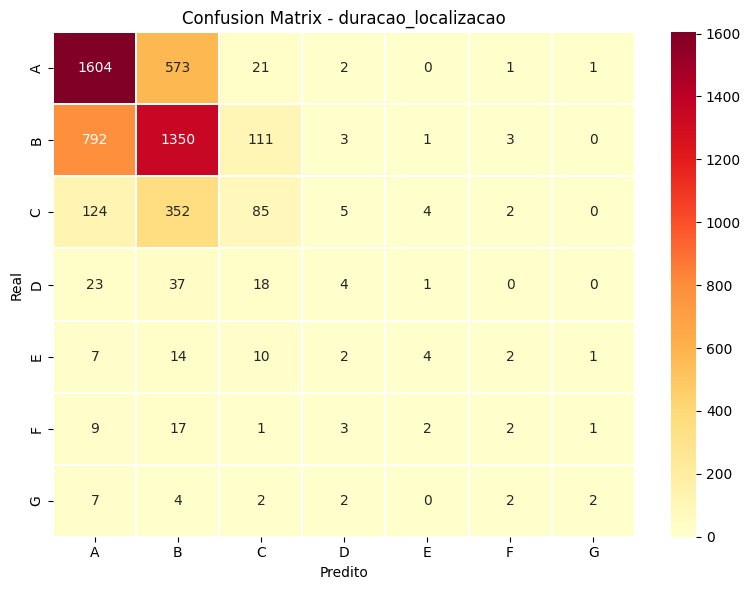

Ranking 4 - localizacao_causa (10.01s)


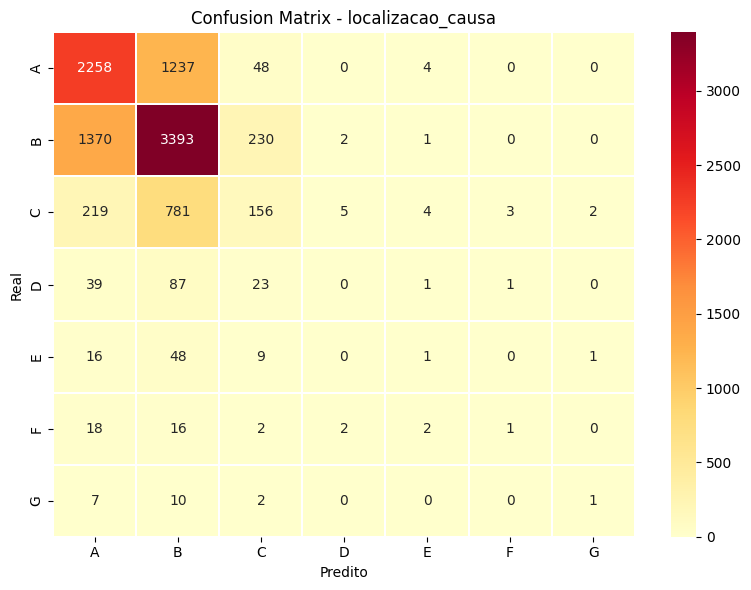

Ranking 5 - todos_sem_fire_size (10.97s)


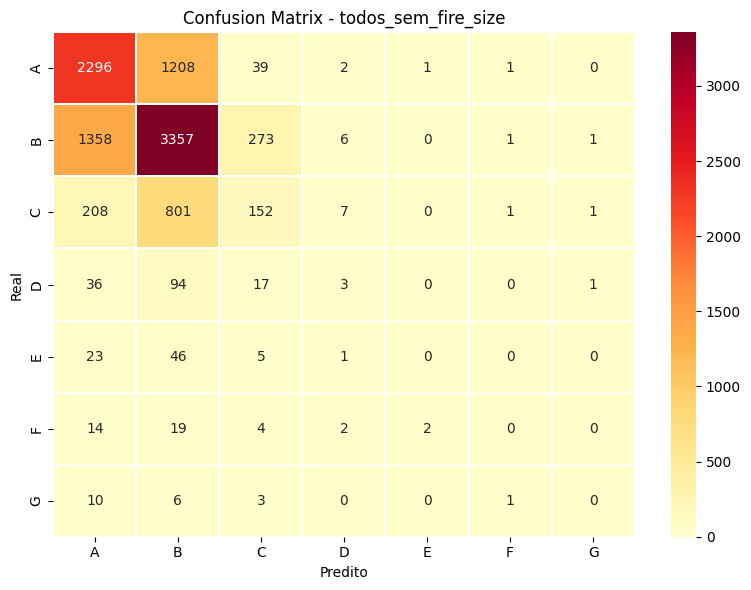

Ranking 6 - duracao_localizacao_causa (2.85s)


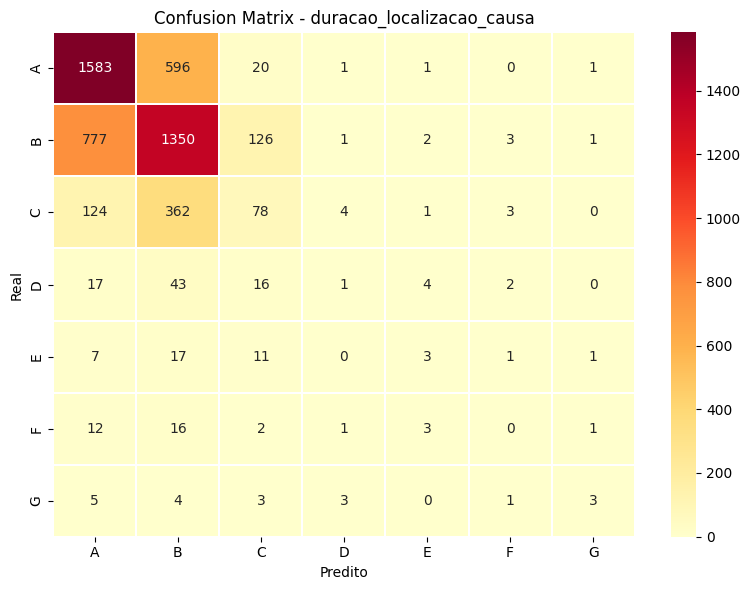

Ranking 7 - localizacao_estado_ano_diaAno (10.92s)


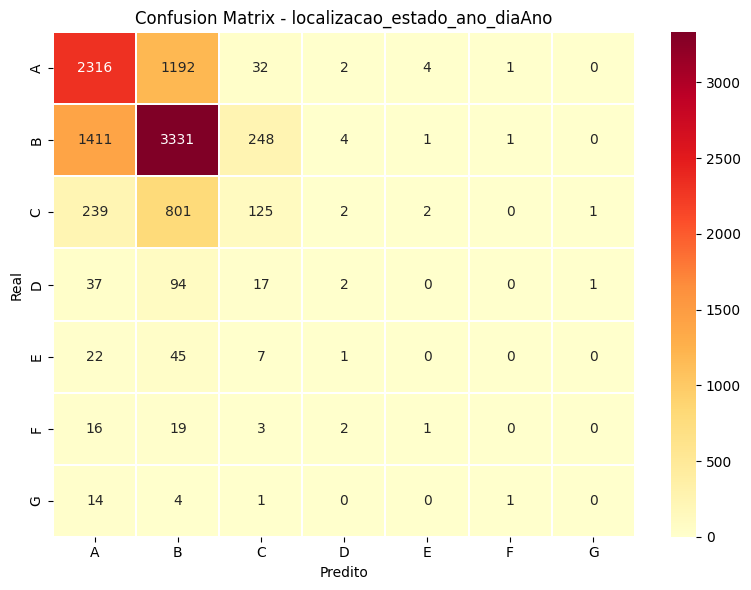

Ranking 8 - localizacao_estado (9.23s)


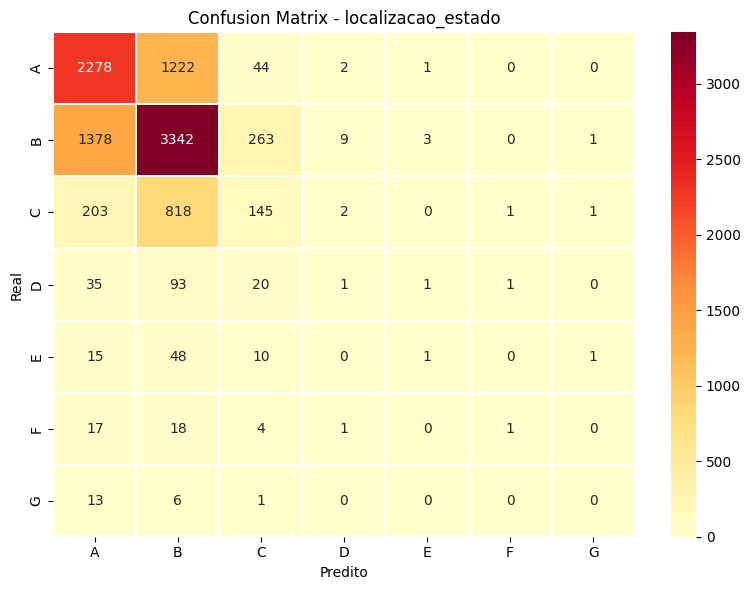

Ranking 9 - localizacao (0.19s)


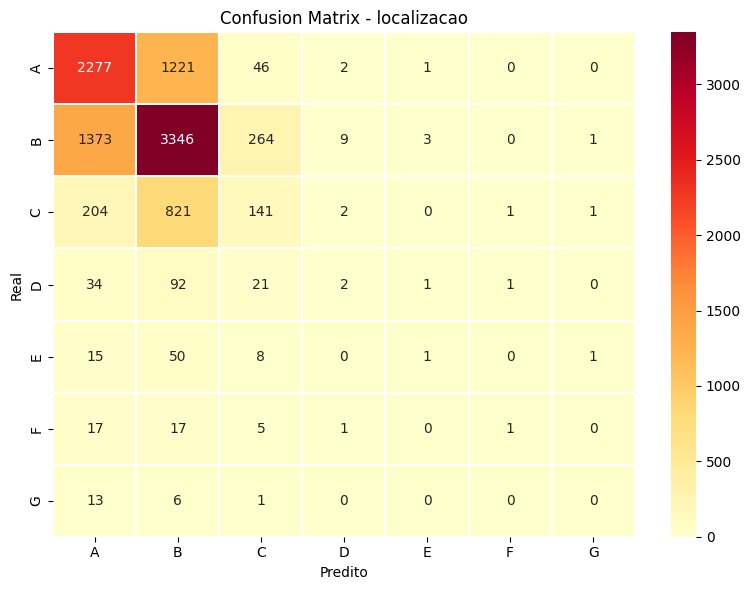

Ranking 10 - localizacao_estado_causa (10.59s)


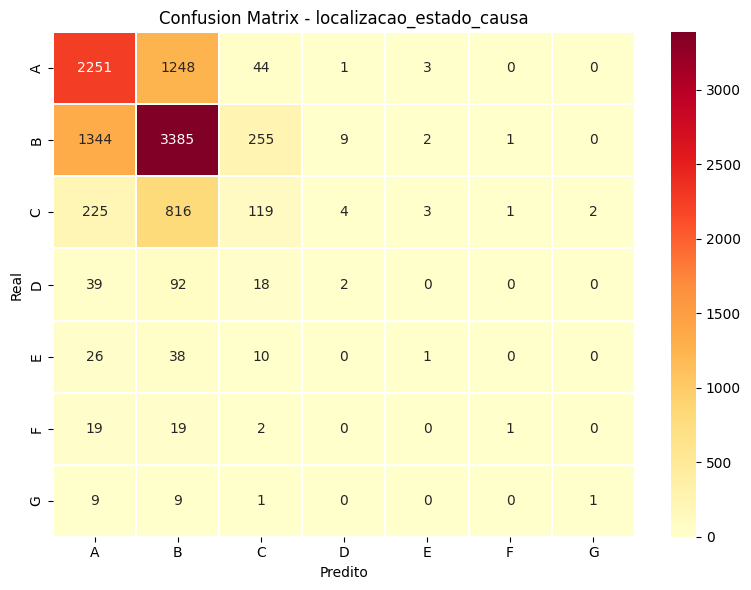

Ranking 11 - owner_localizacao (0.14s)


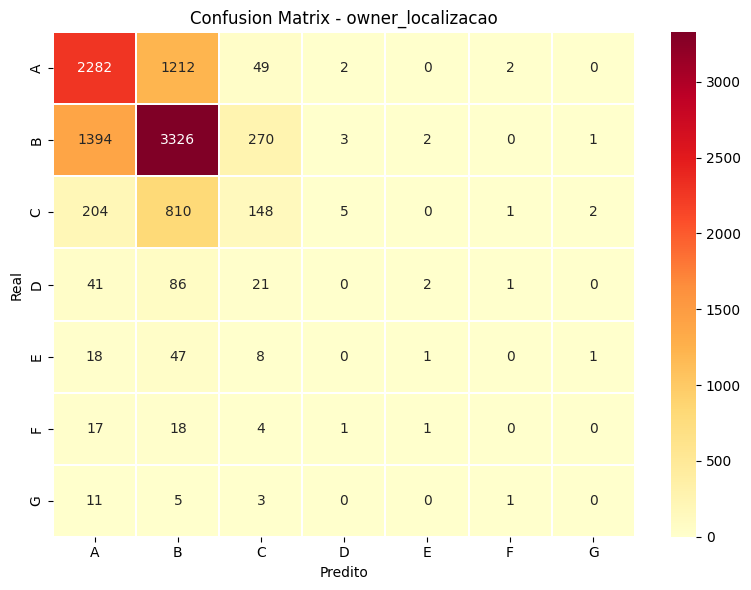

Ranking 12 - localizacao_tempo (0.14s)


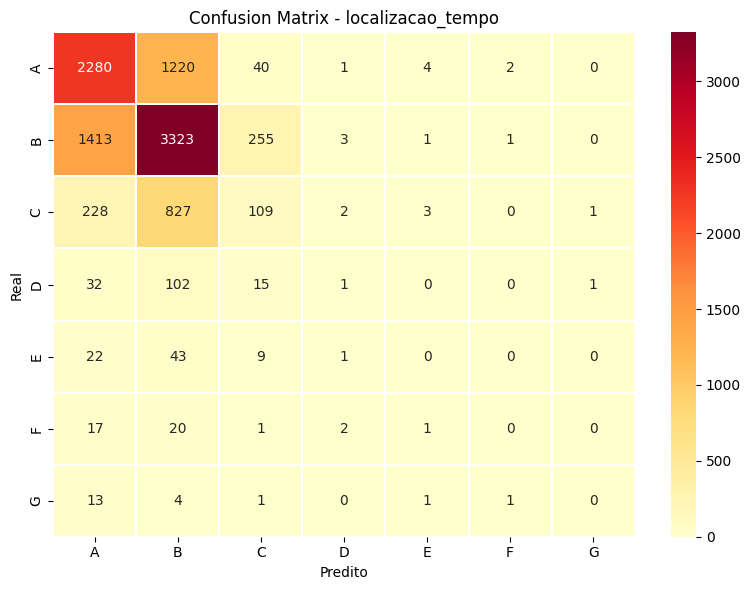

Ranking 13 - estado (4.93s)


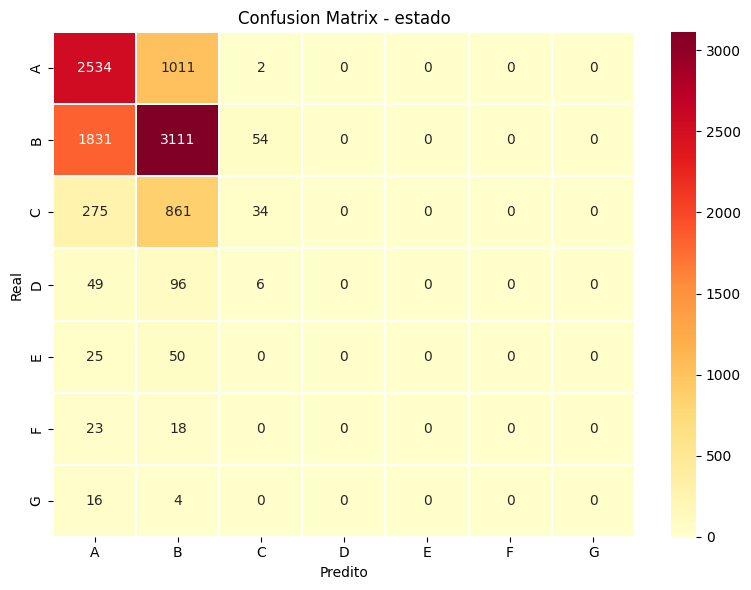

Ranking 14 - county_causa (2.52s)


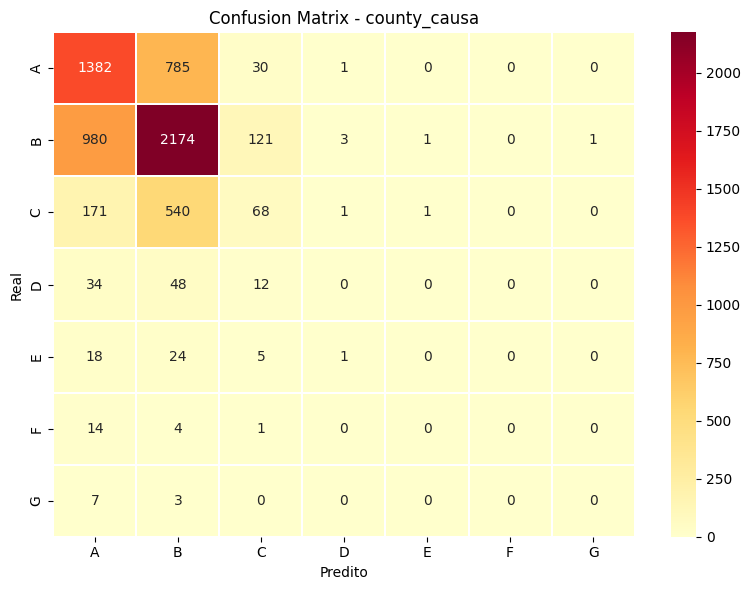

Ranking 15 - hora_localizacao (2.82s)


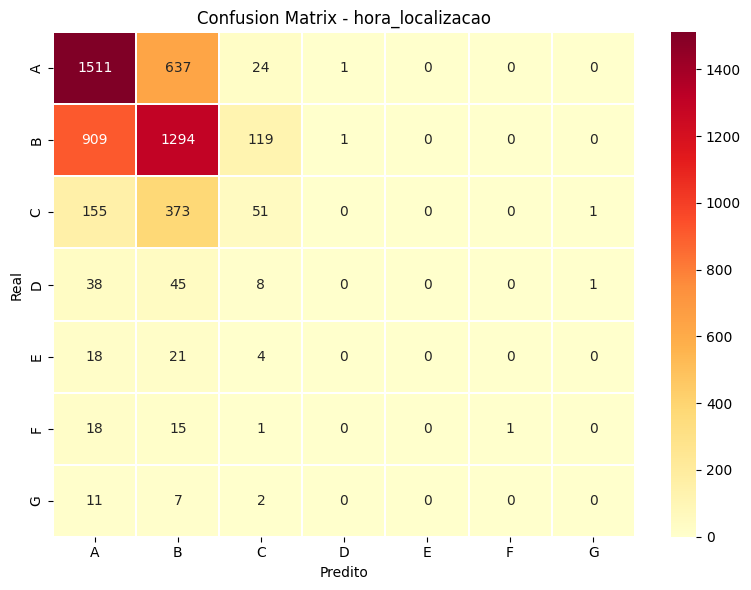

Ranking 16 - causa_estado (6.36s)


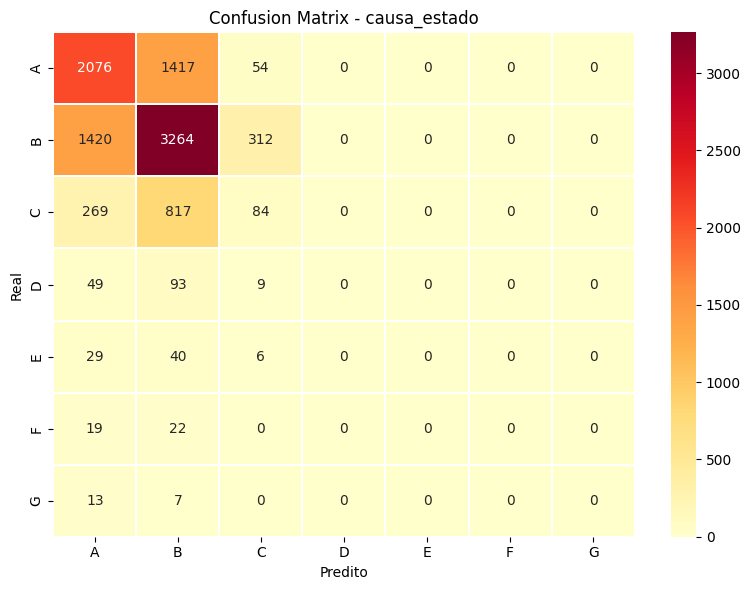

Ranking 17 - owner_causa (8.92s)


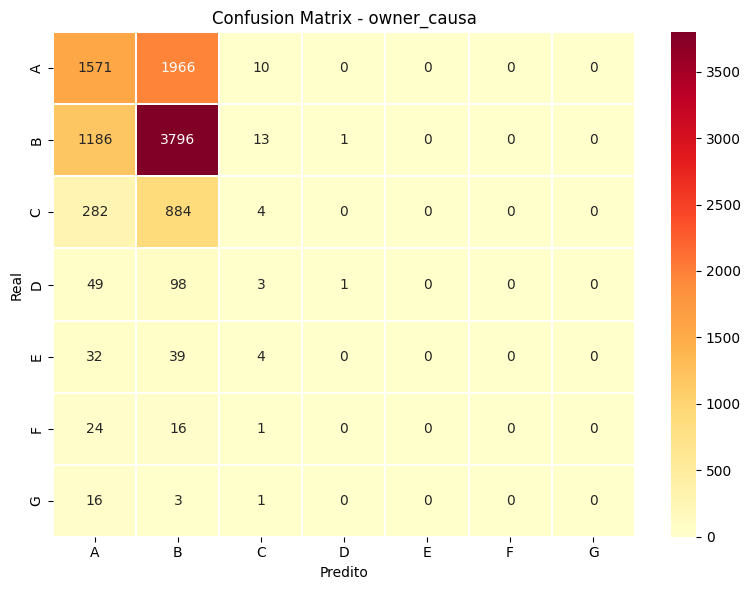

Ranking 18 - tempo (0.14s)


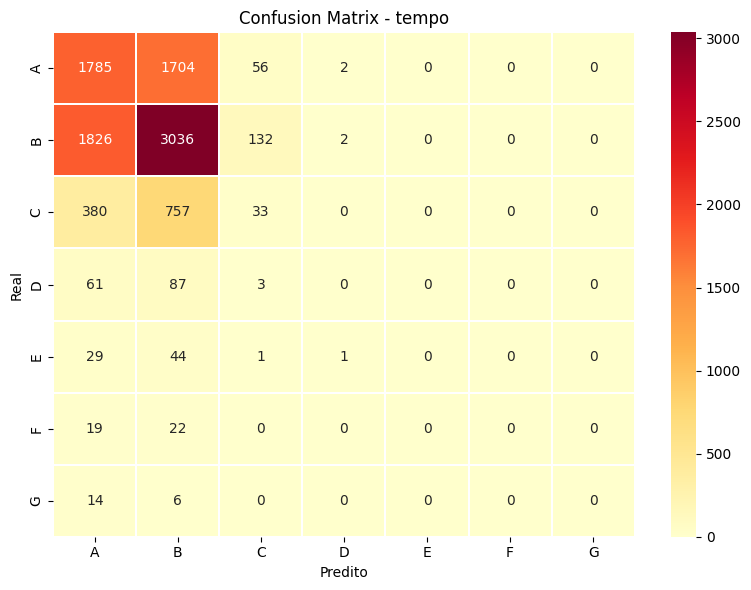

Ranking 19 - causa (5.94s)


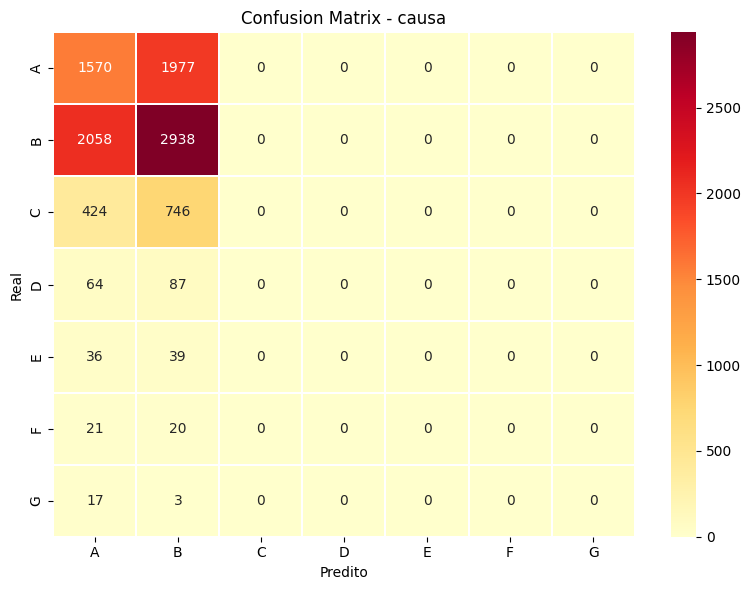

Ranking 20 - hora_descoberta (1.21s)


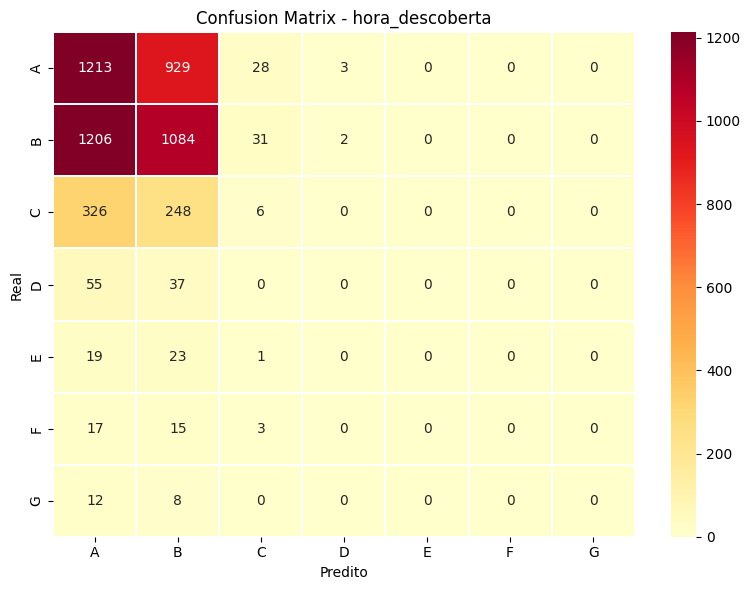

Ranking 21 - duracao (0.34s)


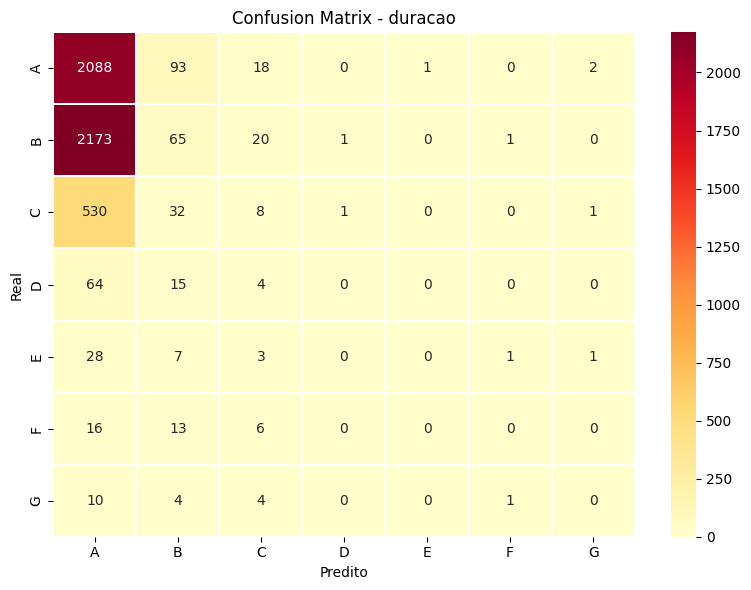

Ranking 22 - owner (0.65s)


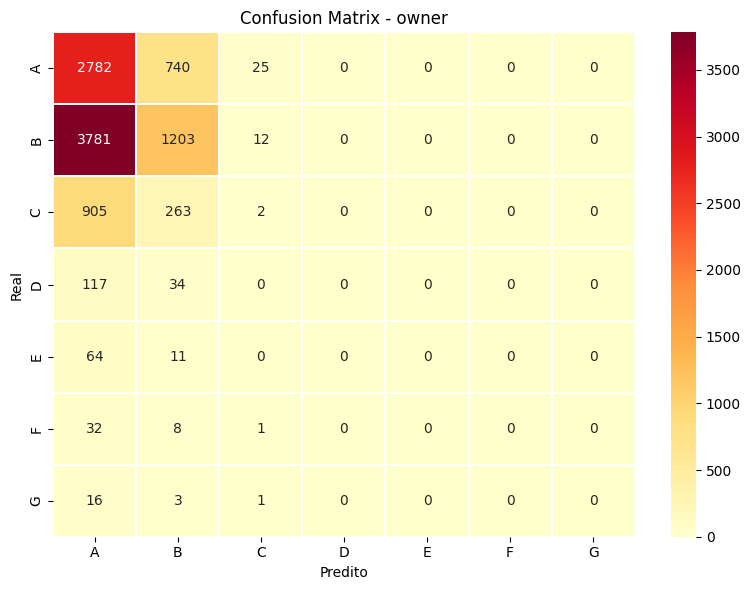


Melhor conjunto de features: completo_com_duracao
Acuracia: 60.25%
F1-score: 0.5823
Tempo: 1.09s
Colunas usadas: ['DURACAO', 'LATITUDE', 'LONGITUDE', 'STATE', 'COUNTY', 'DISCOVERY_DOY', 'DISCOVERY_TIME', 'STAT_CAUSE_DESCR', 'OWNER_CODE']


In [51]:
import time

y_train = train_df[TARGET]
y_test = test_df[TARGET]

results = []
trained_models = {}
feature_names = list(FEATURES.keys())
elapsed_times = {}

for idx, (feature_name, feature_columns) in enumerate(FEATURES.items()):
    show_feature_loading_status(feature_names, idx, elapsed_times)

    start_time = time.perf_counter()

    model = create_pipeline(feature_columns, "knn")
    accuracy, cm, f1, labels = fit_accuracy_cm_f1(model, feature_columns)

    elapsed = time.perf_counter() - start_time
    elapsed_times[feature_name] = elapsed

    results.append(
        {
            "feature_set": feature_name,
            "accuracy": accuracy,
            "f1_score": f1,
            "tempo_segundos": elapsed,
            "confusion_matrix": cm,
            "labels": labels,
            "features": feature_columns,
        }
    )
    trained_models[feature_name] = model

    # Atualiza a tela movendo o item atual de 🟡 para ✅.
    show_feature_loading_status(feature_names, idx + 1, elapsed_times)

results_df = show_model_ranking(results)

best_feature_name = results_df.iloc[0]["feature_set"]
best_feature_columns = FEATURES[best_feature_name]
best_knn_model = trained_models[best_feature_name]

print(f"\nMelhor conjunto de features: {best_feature_name}")
print(f"Acuracia: {results_df.iloc[0]['accuracy']:.2%}")
print(f"F1-score: {results_df.iloc[0]['f1_score']:.4f}")
print(f"Tempo: {results_df.iloc[0]['tempo_segundos']:.2f}s")
print(f"Colunas usadas: {best_feature_columns}")

Progresso por conjunto de features:

localizacao ✅ (1.75s)
localizacao_estado_ano_diaAno ✅ (10.91s)
localizacao_estado_causa ✅ (10.82s)
tempo ✅ (0.73s)
causa ✅ (0.41s)
estado ✅ (0.50s)
localizacao_tempo ✅ (2.25s)
localizacao_causa ✅ (10.54s)
localizacao_estado ✅ (10.94s)
causa_estado ✅ (1.02s)
todos_sem_fire_size ✅ (12.14s)
duracao ✅ (0.22s)
duracao_localizacao ✅ (0.86s)
duracao_localizacao_causa ✅ (3.81s)
hora_descoberta ✅ (2.07s)
hora_localizacao ✅ (4.28s)
owner ✅ (0.46s)
owner_localizacao ✅ (1.84s)
owner_causa ✅ (0.71s)
county_localizacao ✅ (7.14s)
county_causa ✅ (5.55s)
completo_com_duracao ✅ (2.28s)


,ranking,feature_set,accuracy,f1_score,tempo
0,1,completo_com_duracao,64.27%,0.6119,2.28s
1,2,todos_sem_fire_size,61.36%,0.5892,12.14s
2,3,localizacao_tempo,61.06%,0.5816,2.25s
3,4,localizacao_estado_ano_diaAno,61.03%,0.5829,10.91s
4,5,causa_estado,60.36%,0.5554,1.02s
5,6,estado,60.06%,0.5535,0.50s
6,7,localizacao_estado_causa,59.39%,0.5717,10.82s
7,8,county_causa,59.32%,0.5620,5.55s
8,9,duracao_localizacao,57.90%,0.5655,0.86s
9,10,duracao_localizacao_causa,57.90%,0.5651,3.81s



Matriz de confusão por ranking:

Ranking 1 - completo_com_duracao (2.28s)


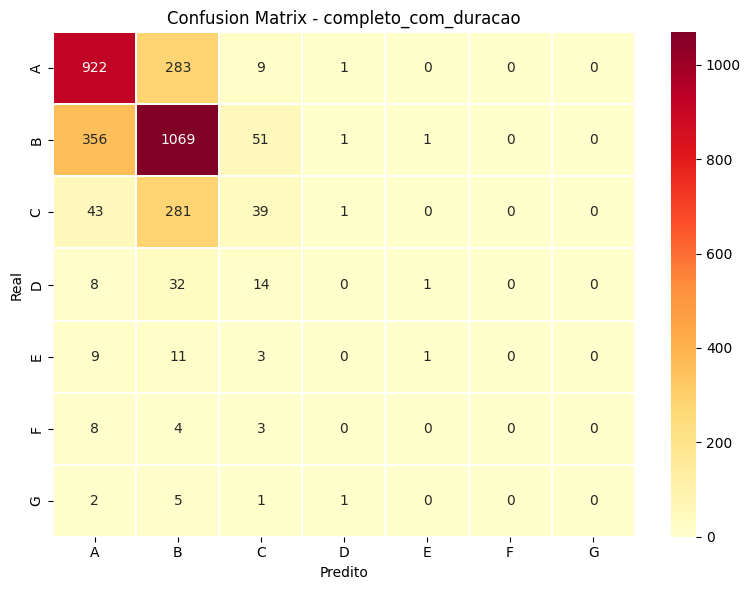

Ranking 2 - todos_sem_fire_size (12.14s)


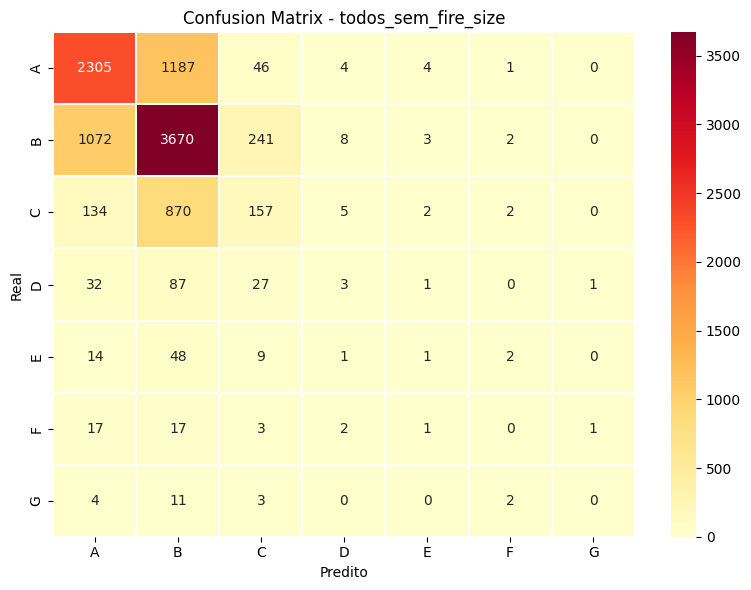

Ranking 3 - localizacao_tempo (2.25s)


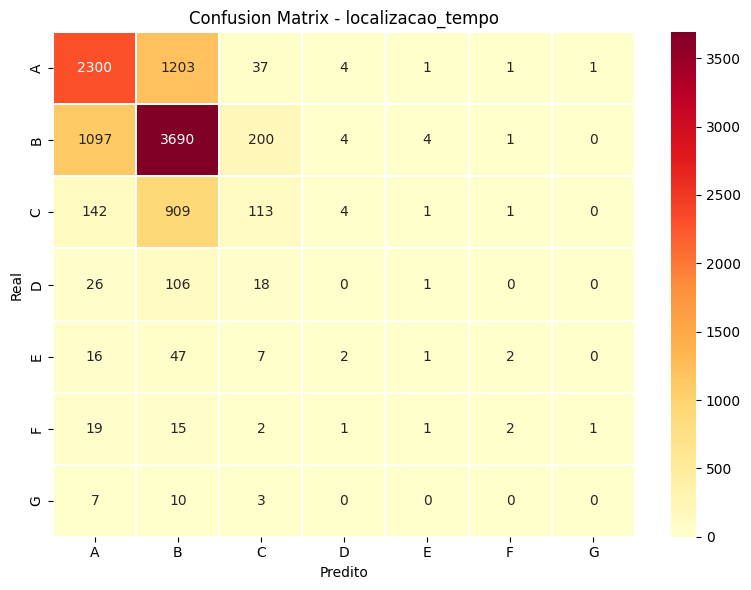

Ranking 4 - localizacao_estado_ano_diaAno (10.91s)


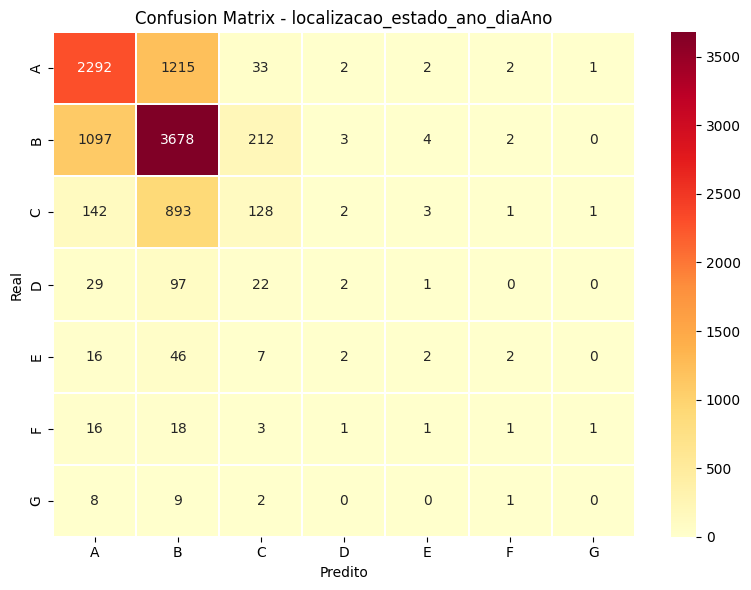

Ranking 5 - causa_estado (1.02s)


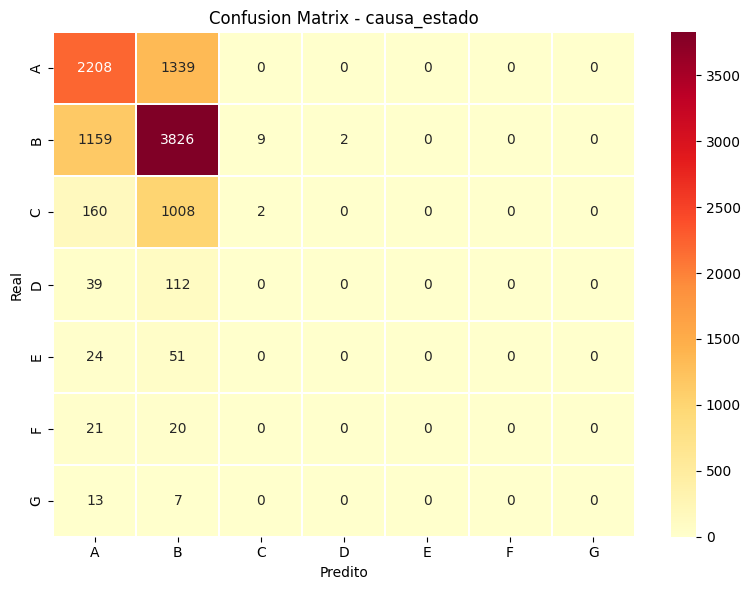

Ranking 6 - estado (0.50s)


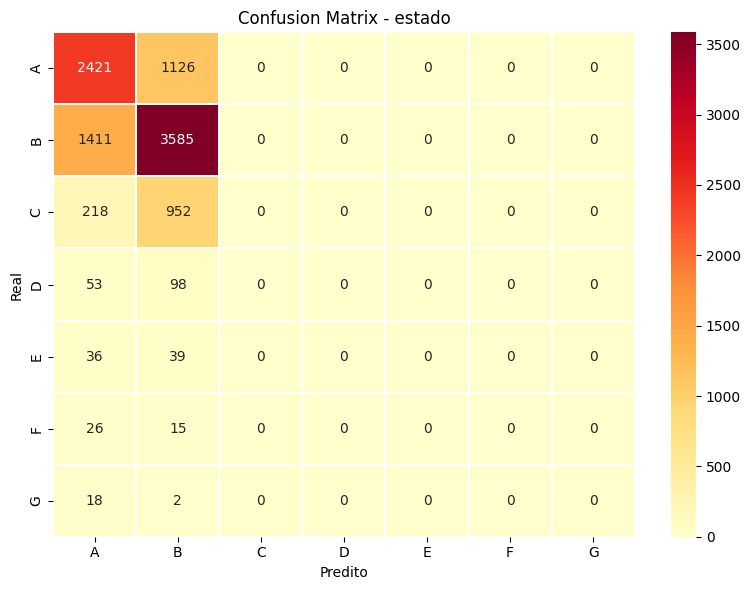

Ranking 7 - localizacao_estado_causa (10.82s)


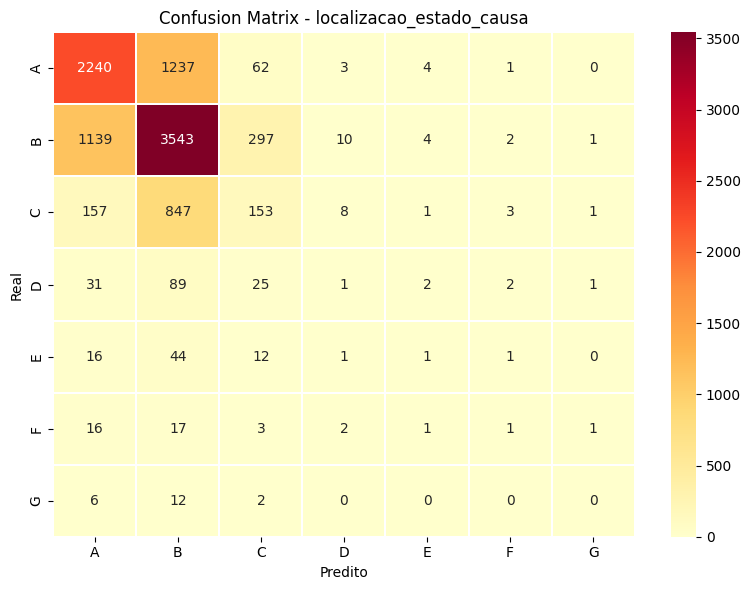

Ranking 8 - county_causa (5.55s)


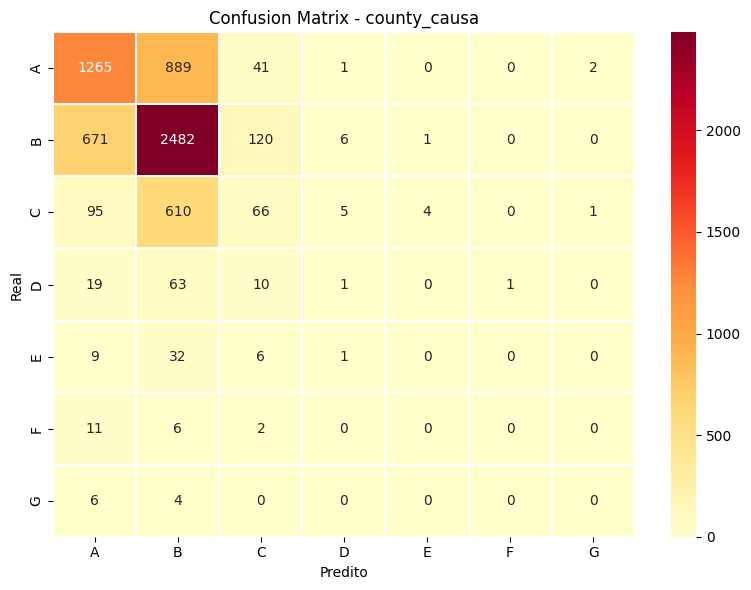

Ranking 9 - duracao_localizacao (0.86s)


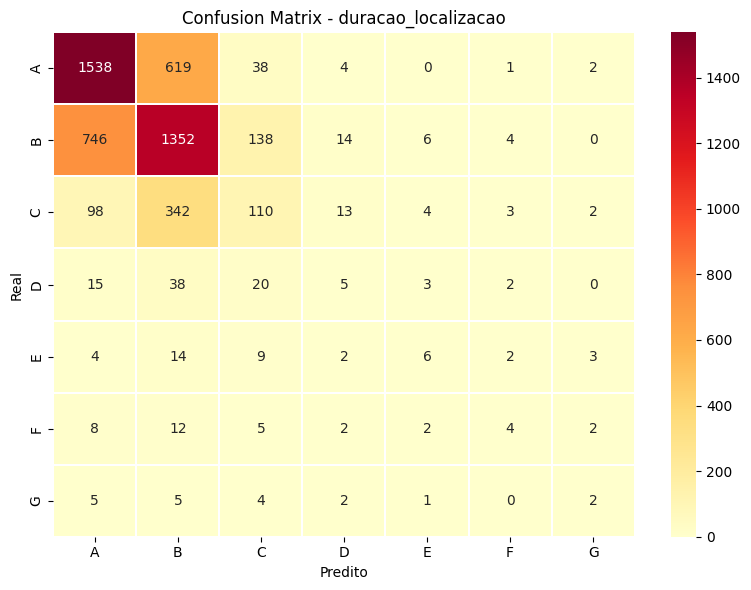

Ranking 10 - duracao_localizacao_causa (3.81s)


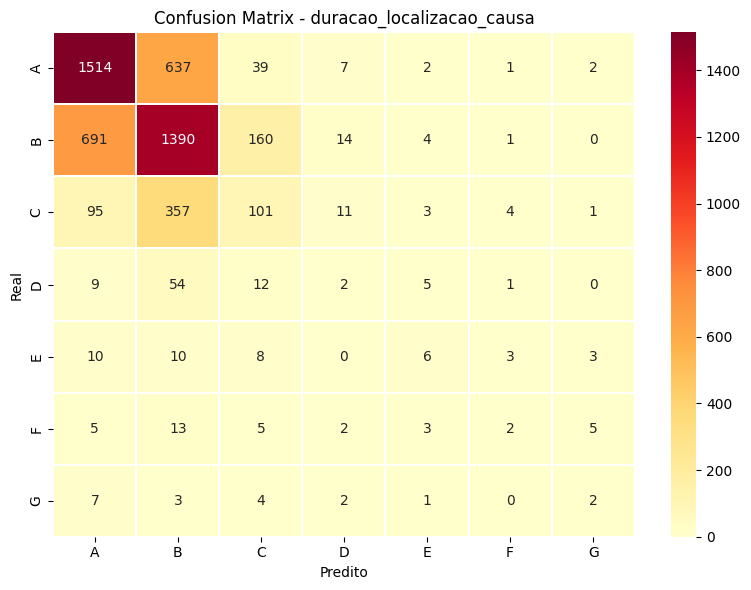

Ranking 11 - hora_localizacao (4.28s)


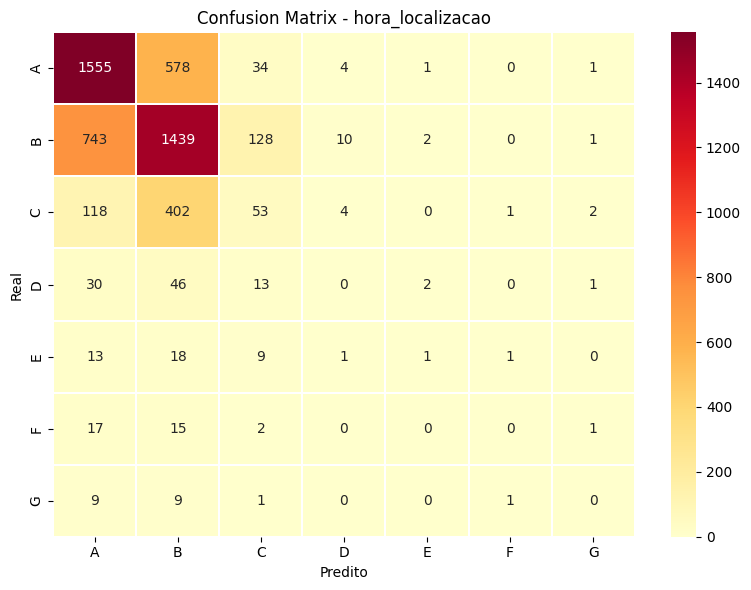

Ranking 12 - localizacao (1.75s)


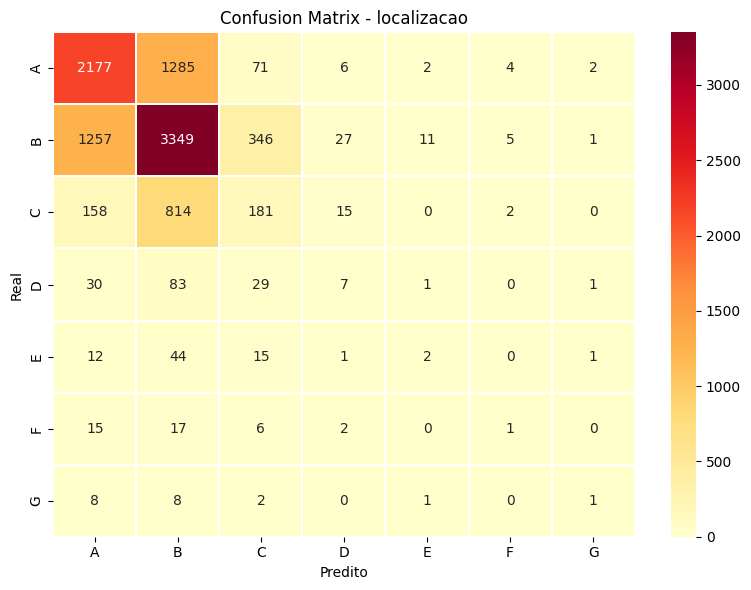

Ranking 13 - county_localizacao (7.14s)


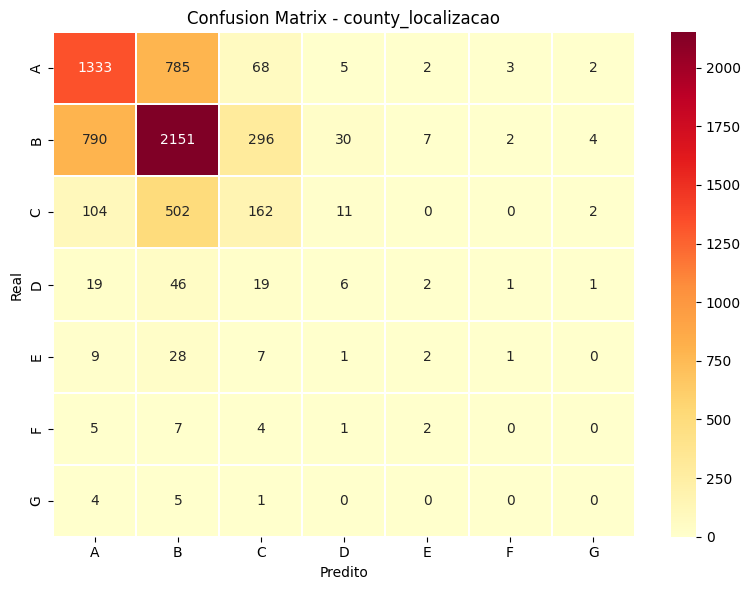

Ranking 14 - localizacao_estado (10.94s)


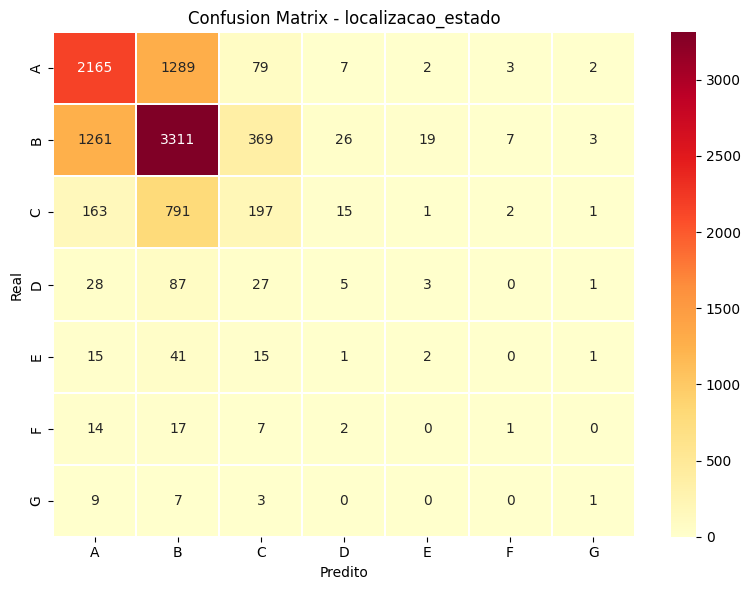

Ranking 15 - localizacao_causa (10.54s)


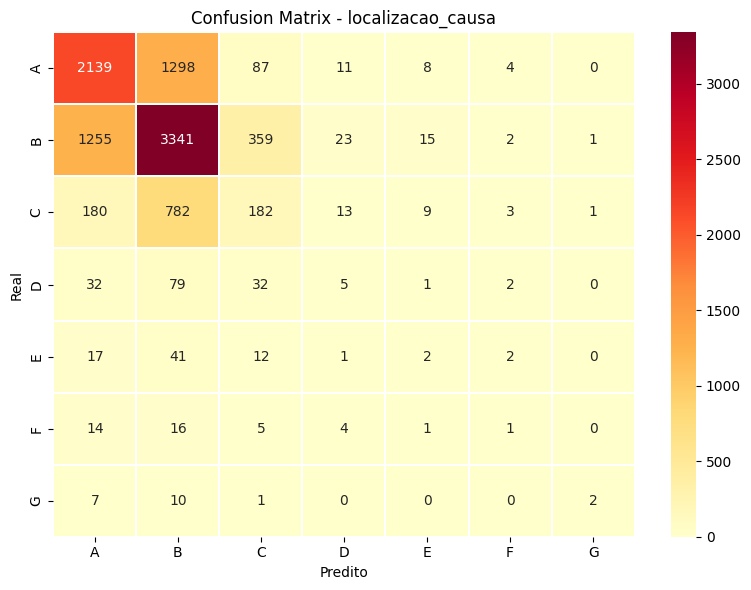

Ranking 16 - owner_localizacao (1.84s)


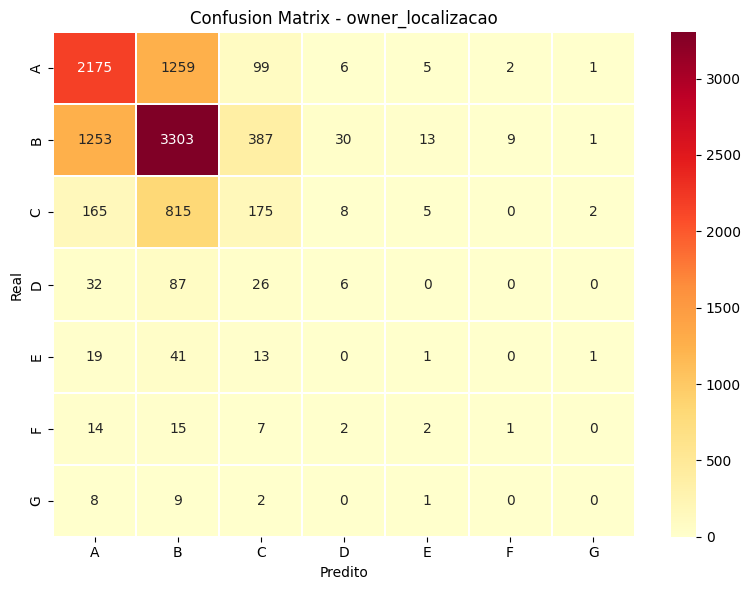

Ranking 17 - owner_causa (0.71s)


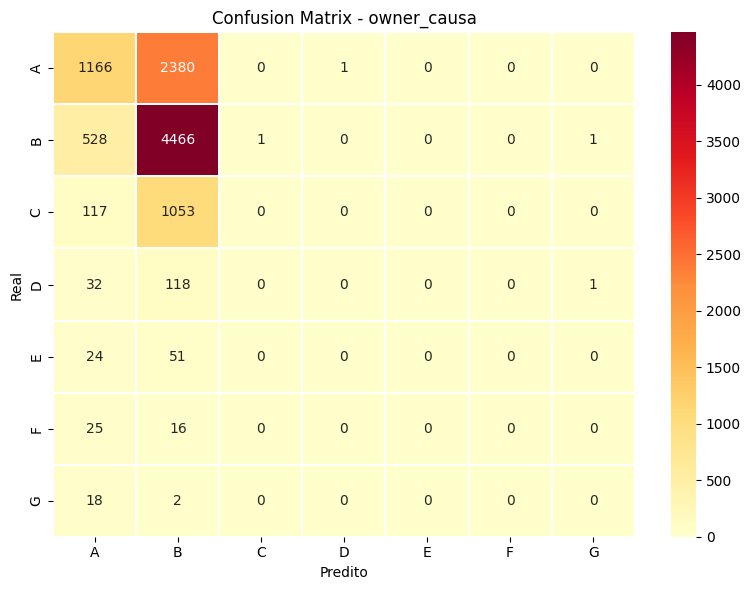

Ranking 18 - owner (0.46s)


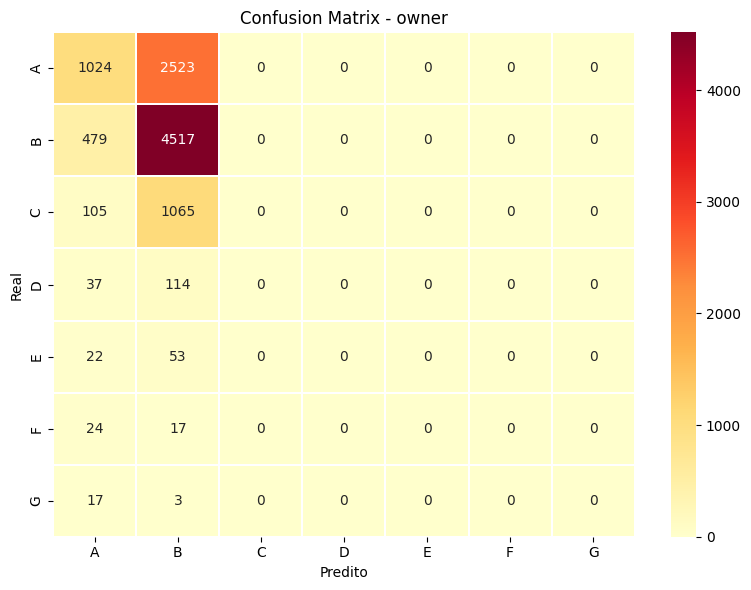

Ranking 19 - causa (0.41s)


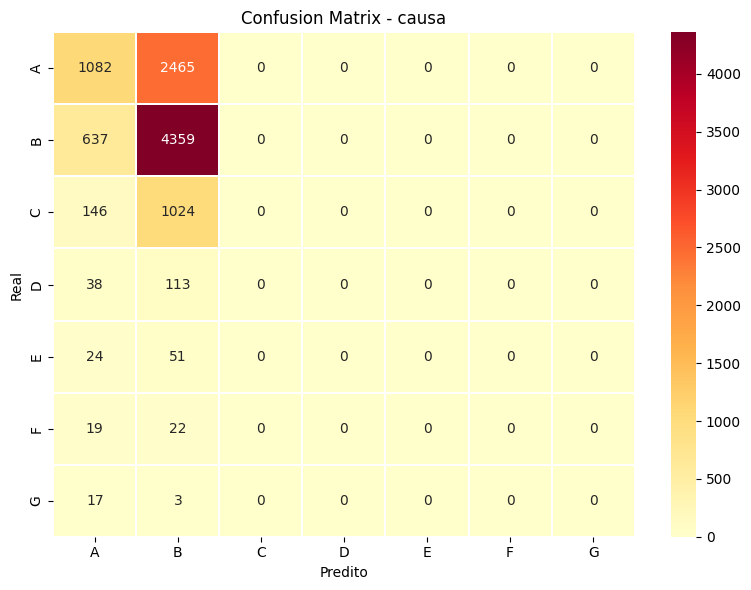

Ranking 20 - tempo (0.73s)


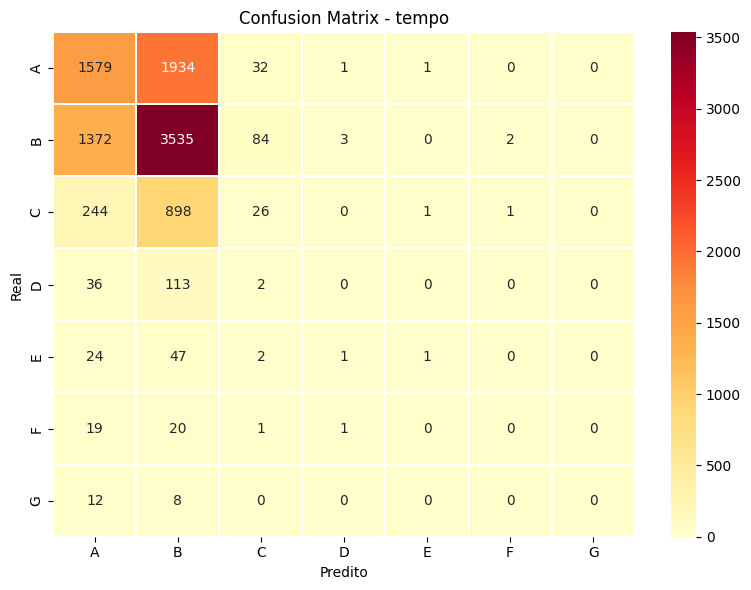

Ranking 21 - hora_descoberta (2.07s)


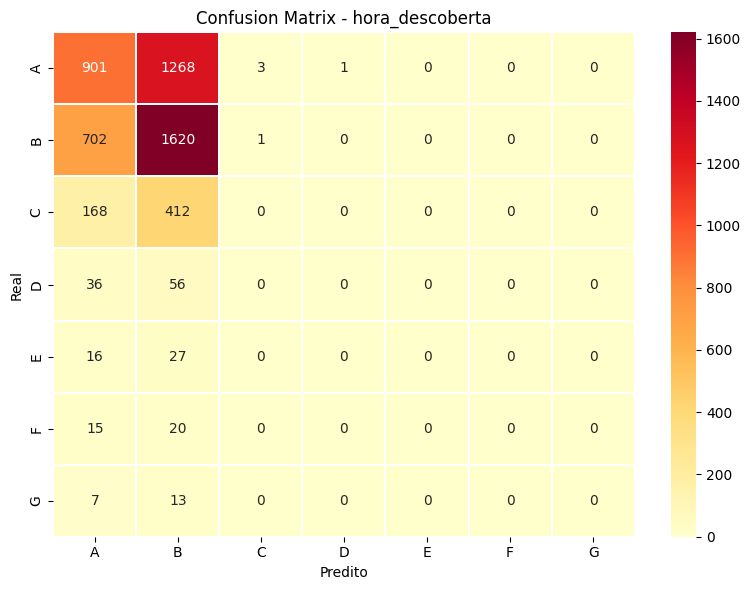

Ranking 22 - duracao (0.22s)


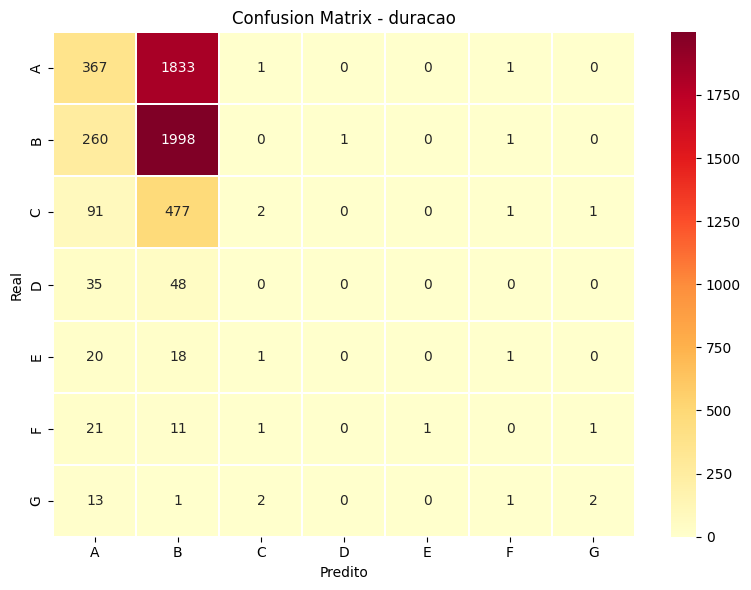


[RF] Melhor conjunto de features: completo_com_duracao
[RF] Acuracia: 64.27%
[RF] F1-score: 0.6119
[RF] Tempo: 2.28s
[RF] Colunas usadas: ['DURACAO', 'LATITUDE', 'LONGITUDE', 'STATE', 'COUNTY', 'DISCOVERY_DOY', 'DISCOVERY_TIME', 'STAT_CAUSE_DESCR', 'OWNER_CODE']


In [52]:
import time

y_train = train_df[TARGET]
y_test = test_df[TARGET]

results_rf = []
trained_models_rf = {}
feature_names = list(FEATURES.keys())
elapsed_times_rf = {}

for idx, (feature_name, feature_columns) in enumerate(FEATURES.items()):
    show_feature_loading_status(feature_names, idx, elapsed_times_rf)

    start_time = time.perf_counter()

    model_rf = create_pipeline(feature_columns, "rf")
    accuracy, cm, f1, labels = fit_accuracy_cm_f1(model_rf, feature_columns)

    elapsed = time.perf_counter() - start_time
    elapsed_times_rf[feature_name] = elapsed

    results_rf.append(
        {
            "feature_set": feature_name,
            "accuracy": accuracy,
            "f1_score": f1,
            "tempo_segundos": elapsed,
            "confusion_matrix": cm,
            "labels": labels,
            "features": feature_columns,
        }
    )
    trained_models_rf[feature_name] = model_rf

    show_feature_loading_status(feature_names, idx + 1, elapsed_times_rf)

results_rf_df = show_model_ranking(results_rf)

best_feature_name_rf = results_rf_df.iloc[0]["feature_set"]
best_feature_columns_rf = FEATURES[best_feature_name_rf]
best_rf_model = trained_models_rf[best_feature_name_rf]

print(f"\n[RF] Melhor conjunto de features: {best_feature_name_rf}")
print(f"[RF] Acuracia: {results_rf_df.iloc[0]['accuracy']:.2%}")
print(f"[RF] F1-score: {results_rf_df.iloc[0]['f1_score']:.4f}")
print(f"[RF] Tempo: {results_rf_df.iloc[0]['tempo_segundos']:.2f}s")
print(f"[RF] Colunas usadas: {best_feature_columns_rf}")

Progresso por conjunto de features:

localizacao ✅ (2.15s)
localizacao_estado_ano_diaAno ✅ (7.13s)
localizacao_estado_causa ✅ (3.59s)
tempo ✅ (3.35s)
causa ✅ (1.27s)
estado ✅ (1.40s)
localizacao_tempo ✅ (2.21s)
localizacao_causa ✅ (2.79s)
localizacao_estado ✅ (2.43s)
causa_estado ✅ (2.98s)
todos_sem_fire_size ✅ (3.64s)
duracao ✅ (0.56s)
duracao_localizacao ✅ (1.85s)
duracao_localizacao_causa ✅ (1.95s)
hora_descoberta ✅ (1.49s)
hora_localizacao ✅ (1.55s)
owner ✅ (1.90s)
owner_localizacao ✅ (4.39s)
owner_causa ✅ (3.23s)
county_localizacao ✅ (2.53s)
county_causa ✅ (2.54s)
completo_com_duracao ✅ (1.54s)


,ranking,feature_set,accuracy,f1_score,tempo
0,1,completo_com_duracao,63.32%,0.5999,1.54s
1,2,county_localizacao,62.16%,0.5720,2.53s
2,3,todos_sem_fire_size,61.83%,0.5754,3.64s
3,4,duracao_localizacao,61.66%,0.5768,1.85s
4,5,localizacao_estado_causa,61.59%,0.5648,3.59s
5,6,localizacao_estado_ano_diaAno,61.52%,0.5645,7.13s
6,7,county_causa,61.21%,0.5724,2.54s
7,8,owner_localizacao,61.18%,0.5614,4.39s
8,9,duracao_localizacao_causa,61.12%,0.5732,1.95s
9,10,localizacao_estado,60.83%,0.5596,2.43s



Matriz de confusão por ranking:

Ranking 1 - completo_com_duracao (1.54s)


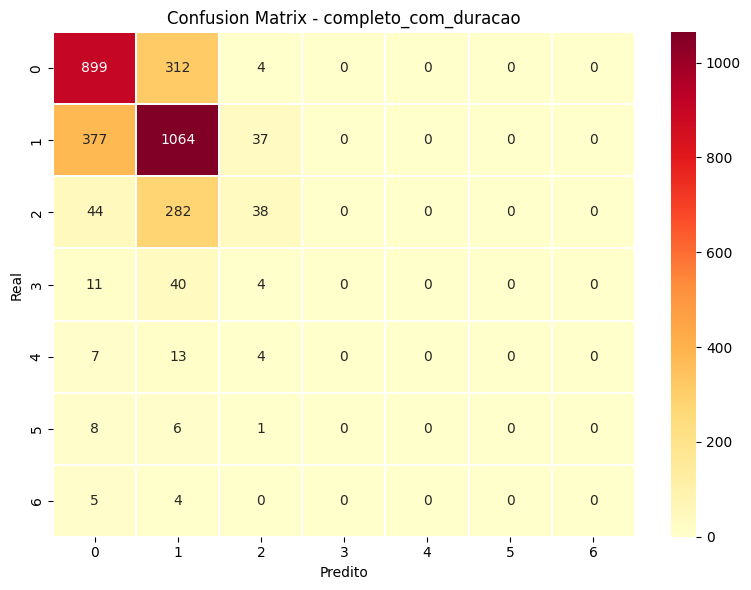

Ranking 2 - county_localizacao (2.53s)


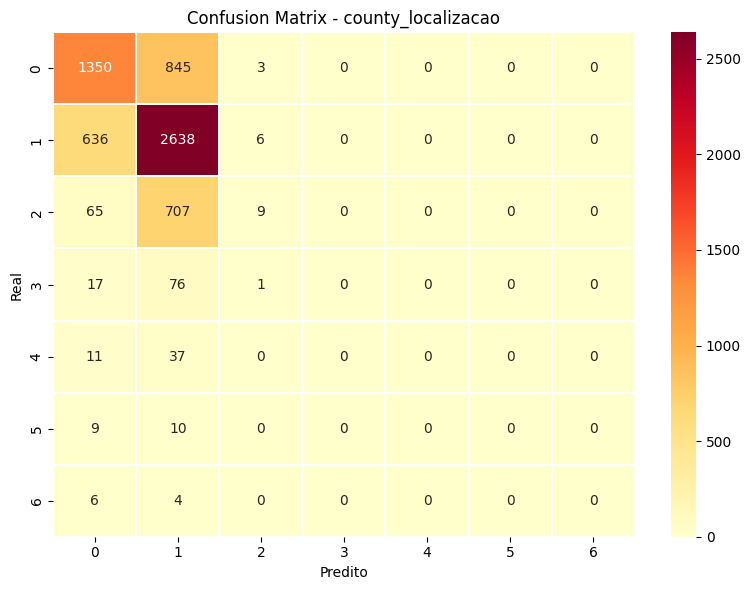

Ranking 3 - todos_sem_fire_size (3.64s)


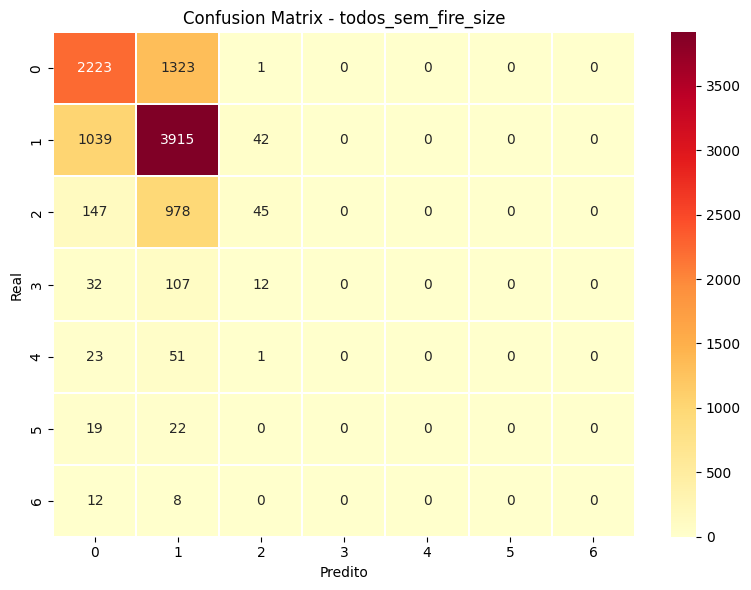

Ranking 4 - duracao_localizacao (1.85s)


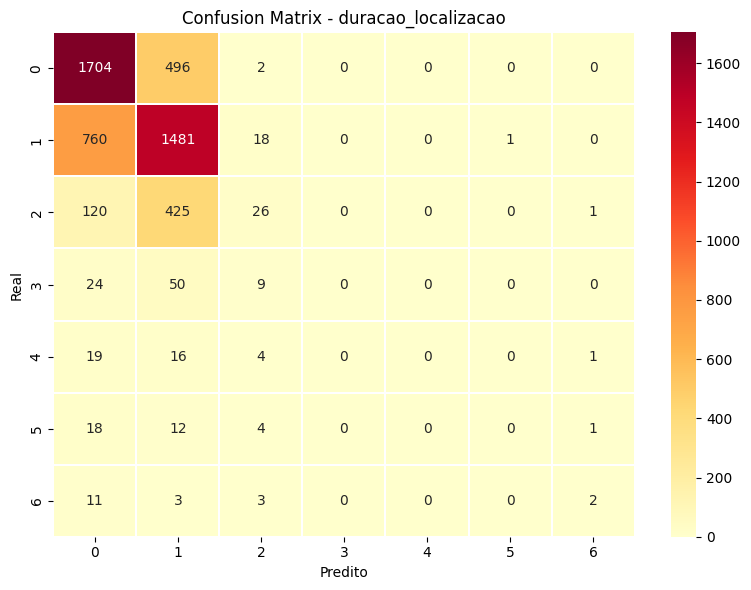

Ranking 5 - localizacao_estado_causa (3.59s)


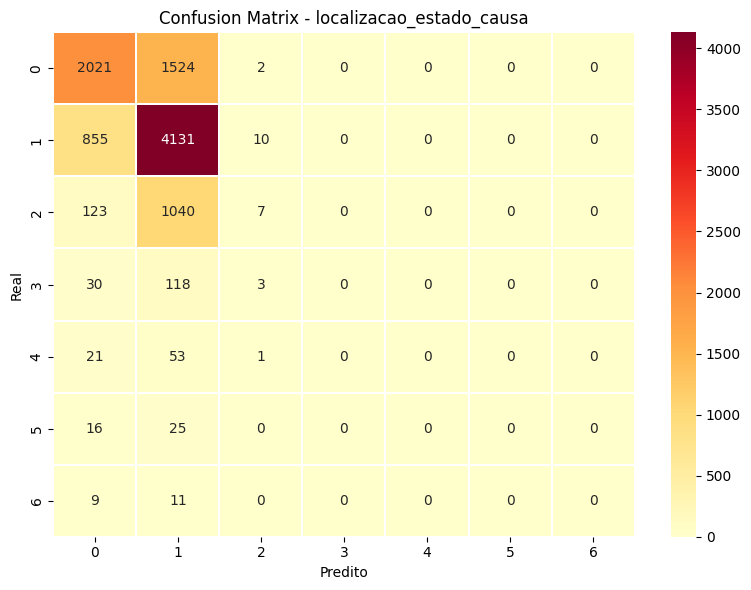

Ranking 6 - localizacao_estado_ano_diaAno (7.13s)


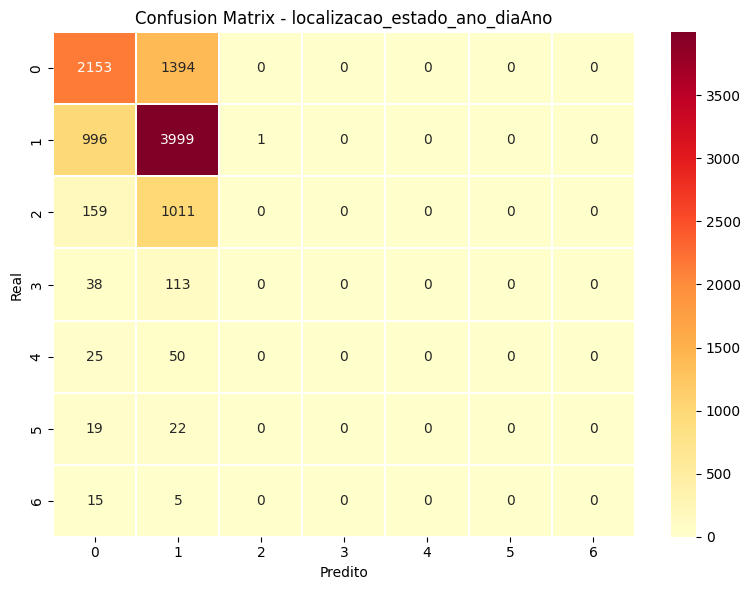

Ranking 7 - county_causa (2.54s)


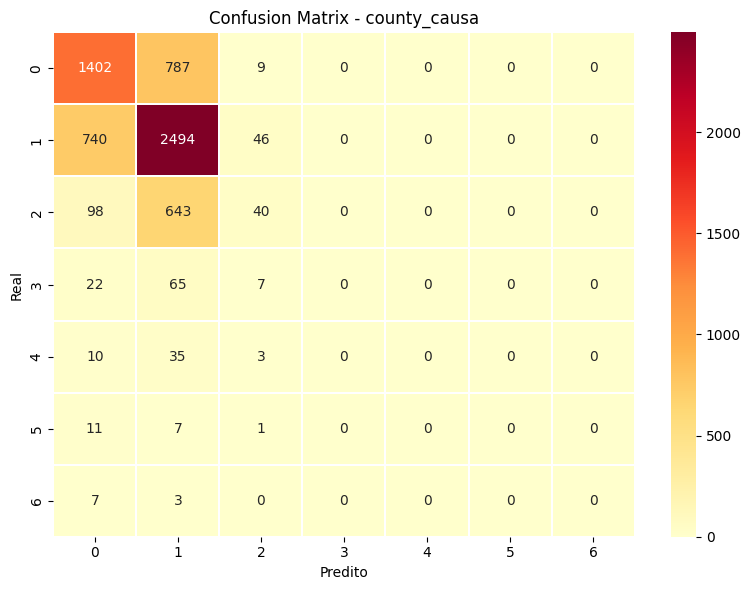

Ranking 8 - owner_localizacao (4.39s)


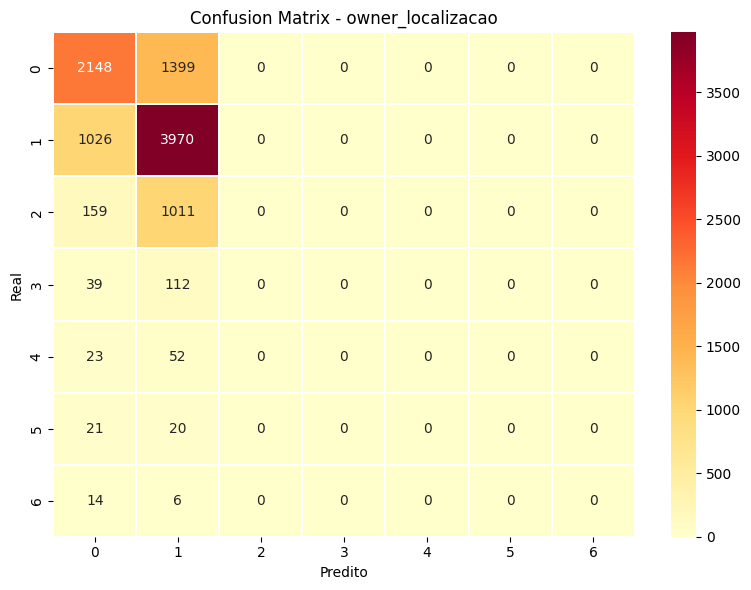

Ranking 9 - duracao_localizacao_causa (1.95s)


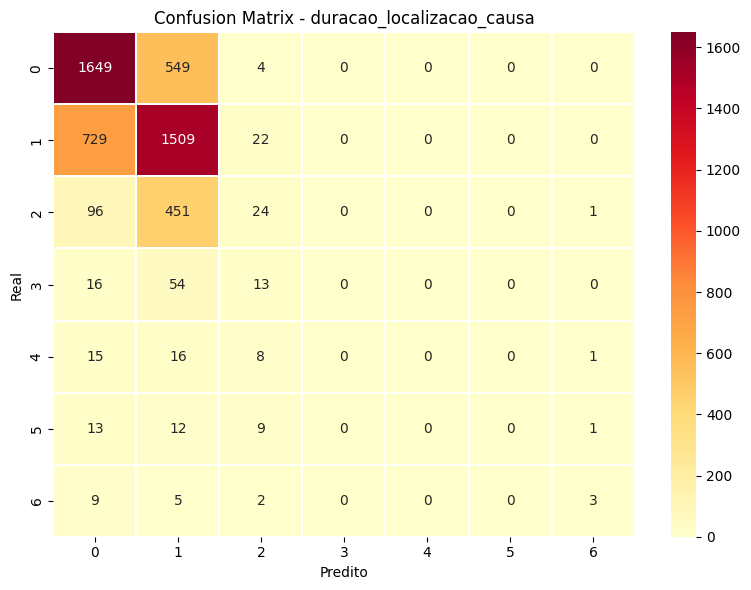

Ranking 10 - localizacao_estado (2.43s)


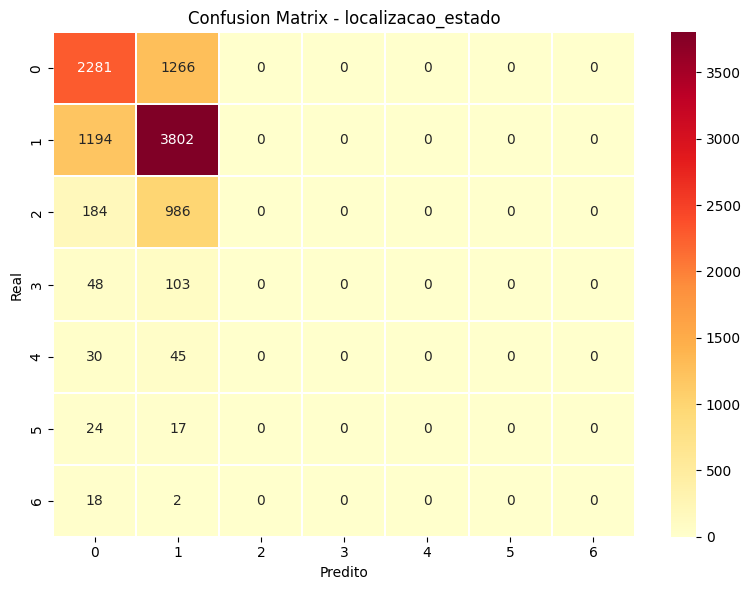

Ranking 11 - localizacao_tempo (2.21s)


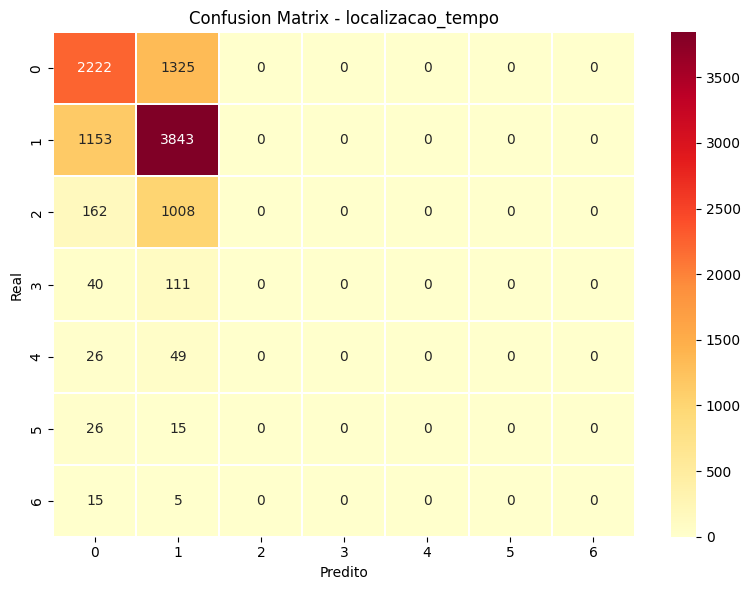

Ranking 12 - causa_estado (2.98s)


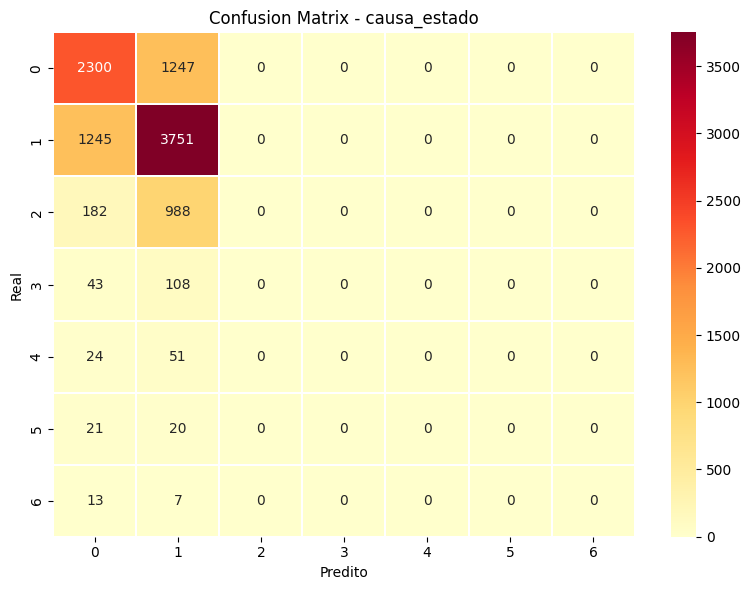

Ranking 13 - localizacao_causa (2.79s)


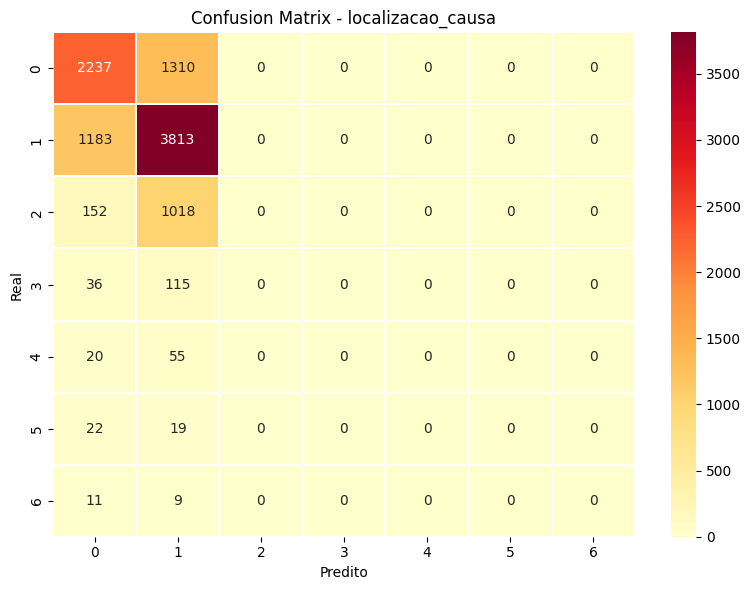

Ranking 14 - localizacao (2.15s)


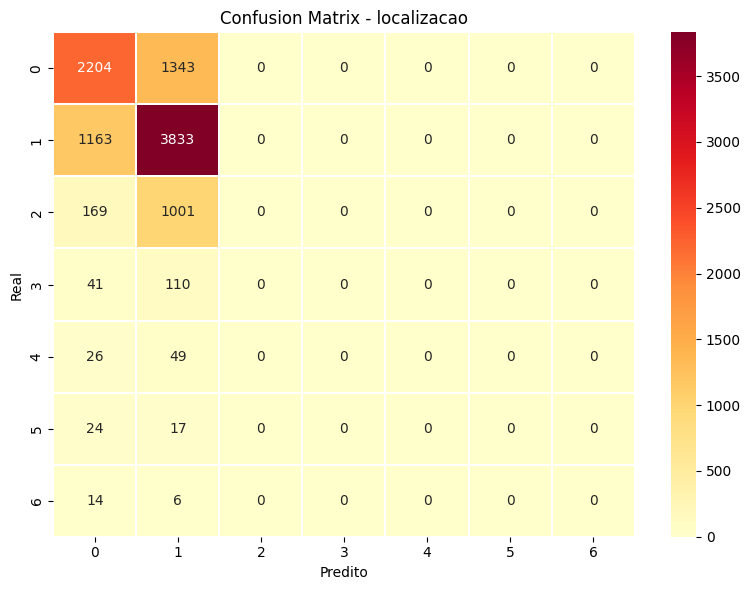

Ranking 15 - estado (1.40s)


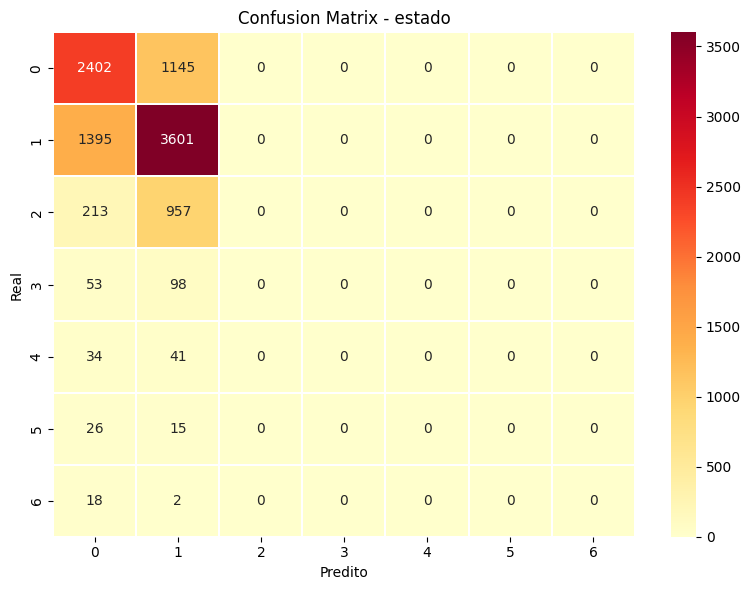

Ranking 16 - hora_localizacao (1.55s)


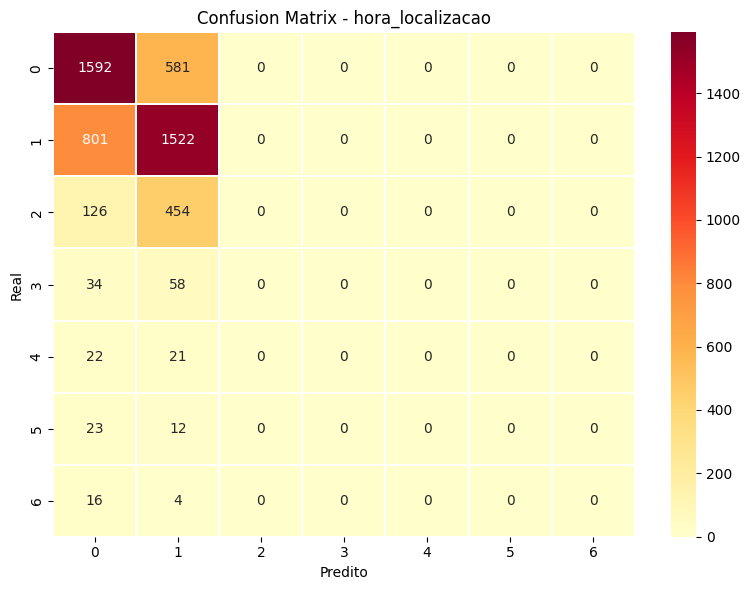

Ranking 17 - owner_causa (3.23s)


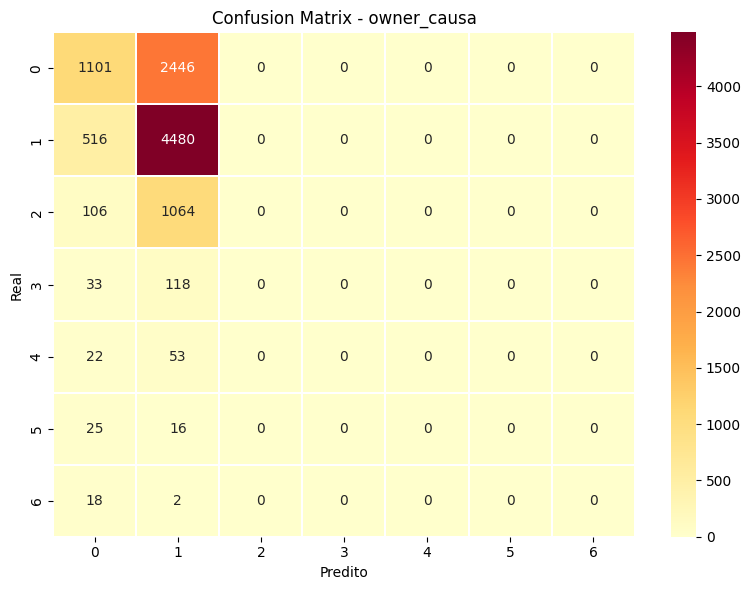

Ranking 18 - owner (1.90s)


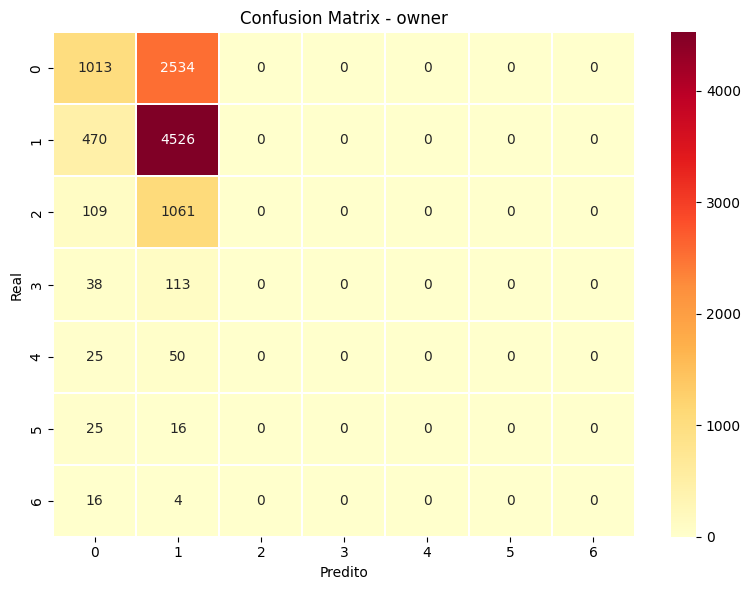

Ranking 19 - causa (1.27s)


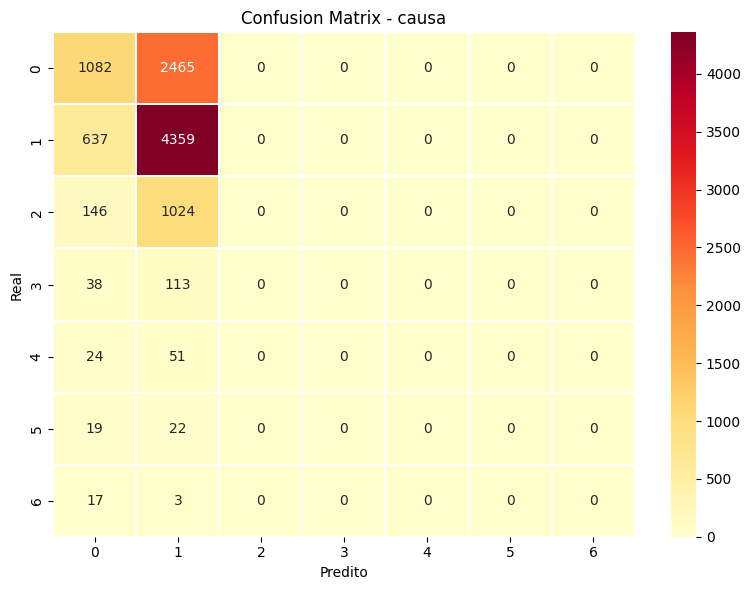

Ranking 20 - tempo (3.35s)


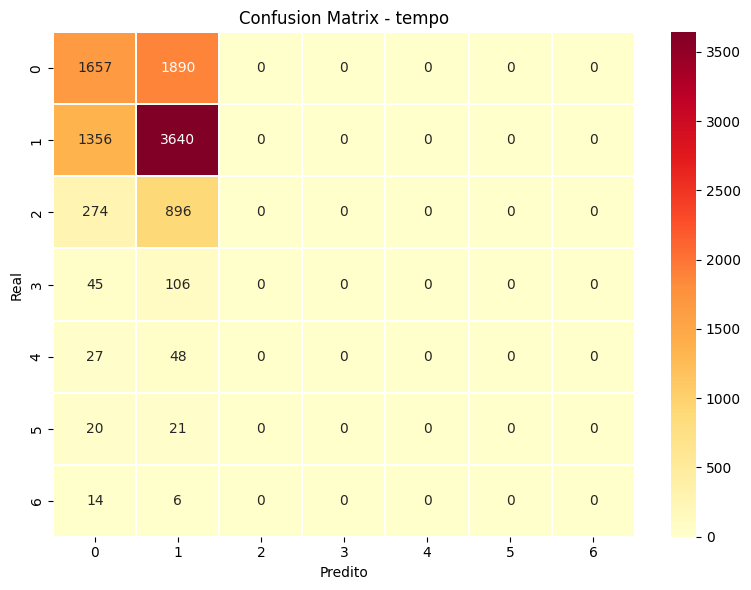

Ranking 21 - hora_descoberta (1.49s)


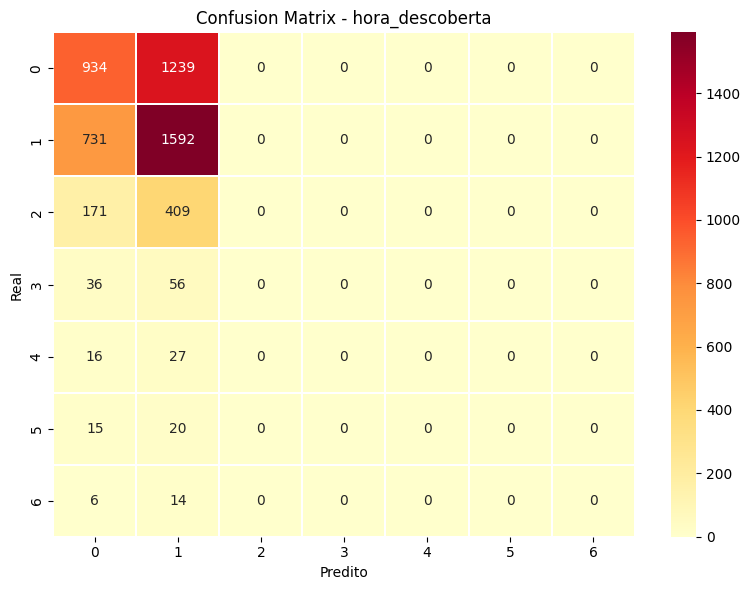

Ranking 22 - duracao (0.56s)


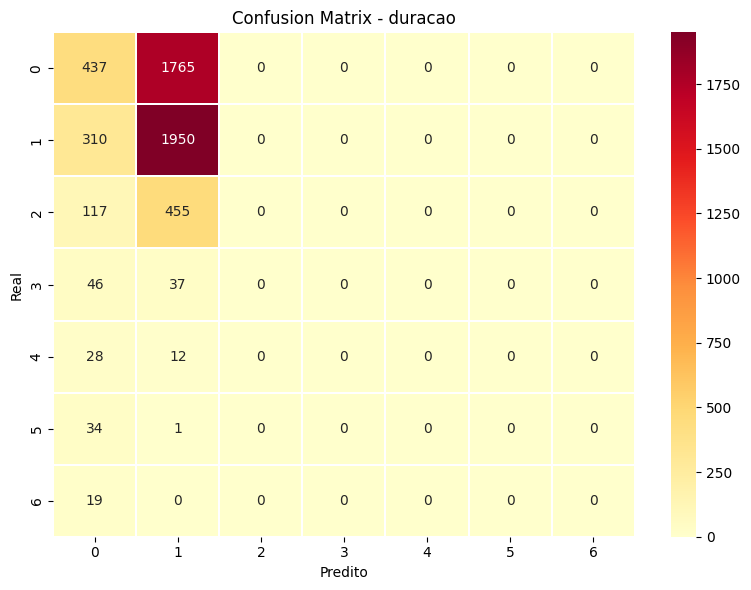


[MLP] Melhor conjunto de features: completo_com_duracao
[MLP] Acuracia: 63.32%
[MLP] F1-score: 0.5999
[MLP] Tempo: 1.54s
[MLP] Colunas usadas: ['DURACAO', 'LATITUDE', 'LONGITUDE', 'STATE', 'COUNTY', 'DISCOVERY_DOY', 'DISCOVERY_TIME', 'STAT_CAUSE_DESCR', 'OWNER_CODE']


In [53]:
import time
from sklearn.preprocessing import LabelEncoder

y_train = train_df[TARGET]
y_test = test_df[TARGET]

# MLP com early_stopping fica estável com target numérico.
label_encoder = LabelEncoder()
y_train_mlp = label_encoder.fit_transform(y_train)
y_test_mlp = label_encoder.transform(y_test)

results_mlp = []
trained_models_mlp = {}
feature_names = list(FEATURES.keys())
elapsed_times_mlp = {}

for idx, (feature_name, feature_columns) in enumerate(FEATURES.items()):
    show_feature_loading_status(feature_names, idx, elapsed_times_mlp)

    start_time = time.perf_counter()

    model_mlp = create_pipeline(feature_columns, "mlp")
    accuracy, cm, f1, labels = fit_accuracy_cm_f1(
        model_mlp,
        feature_columns,
        y_train_input=y_train_mlp,
        y_test_input=y_test_mlp,
    )

    elapsed = time.perf_counter() - start_time
    elapsed_times_mlp[feature_name] = elapsed

    results_mlp.append(
        {
            "feature_set": feature_name,
            "accuracy": accuracy,
            "f1_score": f1,
            "tempo_segundos": elapsed,
            "confusion_matrix": cm,
            "labels": labels,
            "features": feature_columns,
        }
    )
    trained_models_mlp[feature_name] = model_mlp

    show_feature_loading_status(feature_names, idx + 1, elapsed_times_mlp)

results_mlp_df = show_model_ranking(results_mlp)

best_feature_name_mlp = results_mlp_df.iloc[0]["feature_set"]
best_feature_columns_mlp = FEATURES[best_feature_name_mlp]
best_mlp_model = trained_models_mlp[best_feature_name_mlp]

print(f"\n[MLP] Melhor conjunto de features: {best_feature_name_mlp}")
print(f"[MLP] Acuracia: {results_mlp_df.iloc[0]['accuracy']:.2%}")
print(f"[MLP] F1-score: {results_mlp_df.iloc[0]['f1_score']:.4f}")
print(f"[MLP] Tempo: {results_mlp_df.iloc[0]['tempo_segundos']:.2f}s")
print(f"[MLP] Colunas usadas: {best_feature_columns_mlp}")